In [3]:
!pip install momepy

  Using cached libpysal-4.14.1-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.5 MB/s eta 0:00:01
   ------------------ --------------------- 0.8/1.7 MB 1.6 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.2 MB/s  0:00:00
Using cached libpysal-4.14.1-py3-none-any.whl (2.5 MB)

   ---------- ----------------------------- 1/4 [beautifulsoup4]
   ---------- ----------------------------- 1/4 [beautifulsoup4]
   -------------------- ------------------- 2/4 [libpysal]
   -------------------- ------------------- 2/4 [libpysal]
   -------------------- ------------------- 2/4 [libpysal]
   -------------------- ------------------- 2/4 [libpysal]
   -------------------- ------------------- 2/4 [libpysal]
   -----------

In [1]:
!pip install git+https://github.com/alexandermorozzov/connectpt@main

  Cloning https://github.com/alexandermorozzov/connectpt (to revision main) to C:\Users\yanaz\AppData\Local\Temp\pip-req-build-7qwl4lsi
  Resolved https://github.com/alexandermorozzov/connectpt to commit 064fb77c14c57280d0b7095b2413c44247db595c
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for connectpt: filename=connectpt-0.0.post27-py3-none-any.whl size=132687 sha256=00c163c4f5001fd7a4dacdcd44d5069e8e8917d99d8d94cb3e65de0d80109679
  Stored in directory: C:\Users\yanaz\AppData\Local\Temp\pip-ephem-wheel-cache-alvbqql3\wheels\d1\fb\0c\5b7109e243c7833955b3024af915205eda5e044ed1c8cc3c79
Successfully built connectpt


  Running command git clone --filter=blob:none --quiet https://github.com/alexandermorozzov/connectpt 'C:\Users\yanaz\AppData\Local\Temp\pip-req-build-7qwl4lsi'


In [ ]:
# import geopandas as gpd
# from connectpt.preprocess import preprocess, Modality

In [4]:
!git clone https://github.com/alexandermorozzov/connectpt.git

Cloning into 'connectpt'...


In [9]:
import  geopandas as gpd

In [8]:
import pandas as pd
df = pd.read_pickle("gdf_smallest_with_predictions_len_10k.pkl")

In [5]:
gdf = gpd.GeoDataFrame(df, geometry="geometry")

In [14]:
import geopandas as gpd
import numpy as np
import osmnx as ox
import pandas as pd
import time
from tqdm import tqdm
import os
import networkx as nx
import json

import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats
import warnings

from shapely.geometry import LineString, Polygon, Point
import shapely
import pickle
import ast



In [24]:
warnings.filterwarnings('ignore')


def create_overlaid_kde_plots_with_stats(
    gdf,
    feature_columns,
    predictions_col='prediction',
    class_names=None,
    figsize=(12, 7),
    min_samples=5,
    lower_bound=None,
    upper_bound=None,
    lower_percentile=None,
    upper_percentile=None,
    bw_method='scott',
    n_points=400,
    stats_position=(0.98, 0.98),           # координаты блока со статистикой (в долях от осей)
    stats_fontsize=9.2,
    stats_alpha=0.92,
    stats_bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85, boxstyle='round,pad=0.4')
):

    gdf_numeric = gdf.copy()
    for feature in feature_columns:
        if feature in gdf_numeric.columns:
            gdf_numeric[feature] = pd.to_numeric(gdf_numeric[feature], errors='coerce')

    classes = sorted(gdf_numeric[predictions_col].dropna().unique())
    n_classes = len(classes)

    colors = ['#FF8C00', '#1E88E5', '#DC143C', '#2E7D32', '#9467BD', '#FF69B4',
              '#8B4513', '#00CED1', '#FF1493', '#556B2F']

    if class_names is None:
        class_names = [f'Class {c}' for c in classes]

    all_filtered_data = {}
    bounds_info = {}

    for feature in feature_columns:
        feature_data = gdf_numeric[feature].dropna()
        if len(feature_data) < min_samples:
            print(f"Фича '{feature}' пропущена — слишком мало данных ({len(feature_data)})")
            continue

        # Определяем границы обрезки
        if lower_bound is not None and upper_bound is not None:
            lower_limit = lower_bound
            upper_limit = upper_bound
            bounds_info[feature] = f'[{lower_limit:.3f}, {upper_limit:.3f}] (fixed)'
        elif lower_percentile is not None and upper_percentile is not None:
            lower_limit = feature_data.quantile(lower_percentile)
            upper_limit = feature_data.quantile(upper_percentile)
            bounds_info[feature] = f'[{lower_percentile:.0%} – {upper_percentile:.0%}]'
        elif upper_percentile is not None:
            lower_limit = feature_data.min()
            upper_limit = feature_data.quantile(upper_percentile)
            bounds_info[feature] = f'[min – {upper_percentile:.0%}]'
        elif lower_percentile is not None:
            lower_limit = feature_data.quantile(lower_percentile)
            upper_limit = feature_data.max()
            bounds_info[feature] = f'[{lower_percentile:.0%} – max]'
        else:
            lower_limit = feature_data.min()
            upper_limit = feature_data.max()
            bounds_info[feature] = '[min, max]'

        filtered = feature_data[(feature_data >= lower_limit) & (feature_data <= upper_limit)]
        all_filtered_data[feature] = (filtered, lower_limit, upper_limit)

    for feature in feature_columns:
        if feature not in all_filtered_data:
            continue

        filtered_all, lower_limit, upper_limit = all_filtered_data[feature]
        x_range = upper_limit - lower_limit
        if x_range <= 0:
            print(f"Фича '{feature}' — нулевой диапазон после обрезки, пропускаем")
            continue

        x = np.linspace(lower_limit - x_range*0.04, upper_limit + x_range*0.04, n_points)

        fig, ax = plt.subplots(figsize=figsize)

        max_height = 0
        stats_lines = []

        for i, class_val in enumerate(classes):
            data = gdf_numeric[gdf_numeric[predictions_col] == class_val][feature].dropna()

            if len(data) < min_samples:
                continue

            data_trim = data[(data >= lower_limit) & (data <= upper_limit)]

            if len(data_trim) < min_samples:
                print(f"  → класс {class_val} ({class_names[i]}) после обрезки имеет {len(data_trim)} значений — пропущен")
                continue

            try:
                kde = stats.gaussian_kde(data_trim, bw_method=bw_method)
                density = kde(x)
                density_norm = density / density.max() * 0.92

                color = colors[i % len(colors)]

                ax.fill_between(x, 0, density_norm, color=color, alpha=0.28, linewidth=0)
                ax.plot(x, density_norm, color=color, lw=1.9, alpha=0.9, label=class_names[i])

                max_height = max(max_height, density_norm.max())

                # ─── Считаем статистику ───
                n = len(data_trim)
                mean_val = data_trim.mean()
                median_val = data_trim.median()
                std_val = data_trim.std()
                q25 = data_trim.quantile(0.25)
                q75 = data_trim.quantile(0.75)
                iqr = q75 - q25

                stats_lines.append(
                    f"{class_names[i]:<18} "
                    f"n={n:>4}  "
                    f"med={median_val:>6.2f}  "
                    f"mean={mean_val:>6.2f}  "
                    f"sd={std_val:>5.2f}  "
                    f"IQR={iqr:>5.2f}"
                )

            except Exception as e:
                print(f"KDE ошибка для '{feature}' / класс {class_val}: {e}")
                continue

        if max_height == 0:
            print(f"Фича '{feature}' — не удалось построить ни одну кривую")
            plt.close(fig)
            continue

        # ─── Оформление графика ───
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(0, max_height * 1.15)

        ax.set_xlabel('Value', fontsize=11)
        ax.set_ylabel('Normalized density', fontsize=11)

        short_name = feature.replace('Estimate!!Total:', '').replace('Estimate!!', '').strip()
        if len(short_name) > 60:
            short_name = short_name[:57] + '...'

        ax.set_title(f"{short_name}\nby Urban Street Pattern Typology", 
                     fontsize=13, fontweight='bold', pad=14)

        if feature in bounds_info:
            ax.text(0.02, 0.96, f"bounds: {bounds_info[feature]}",
                    transform=ax.transAxes, ha='left', va='top',
                    fontsize=9, color='gray', alpha=0.8)

        ax.legend(loc='upper right', fontsize=9.5, framealpha=0.92,
                  edgecolor='gray', bbox_to_anchor=(0.99, 0.78))

        # ─── Вывод статистики в виде текста ───
        # if stats_lines:
        #     stats_text = "Statistics (after trimming):\n" + "\n".join(stats_lines)
        #     ax.text(
        #         stats_position[0], stats_position[1],
        #         stats_text,
        #         transform=ax.transAxes,
        #         fontsize=stats_fontsize,
        #         fontfamily='monospace',
        #         ha='right',
        #         va='top',
        #         bbox=stats_bbox,
        #         alpha=stats_alpha
        #     )

        ax.grid(True, axis='y', alpha=0.25, linestyle='--', linewidth=0.8)
        ax.tick_params(labelsize=9.5)

        plt.tight_layout()
        plt.show()

In [18]:
print(gdf[['Estimate!!Total:!!Public transportation:', 'Estimate!!Total:']].dtypes)

Estimate!!Total:!!Public transportation:    object
Estimate!!Total:                            object
dtype: object


In [22]:
# Преобразуем оба столбца в числа, ошибки заменяем на NaN
gdf['pt_numeric'] = pd.to_numeric(gdf['Estimate!!Total:!!Public transportation:'], errors='coerce')
gdf['total_numeric'] = pd.to_numeric(gdf['Estimate!!Total:'], errors='coerce')
gdf["car_numeric"] = pd.to_numeric(gdf["Estimate!!Total:!!Car, truck, or van:"], errors='coerce')

# Теперь деление должно работать
gdf["share_pt"] = gdf['pt_numeric'] / gdf['total_numeric']
gdf["share_car"] = gdf["car_numeric"] / gdf['total_numeric']

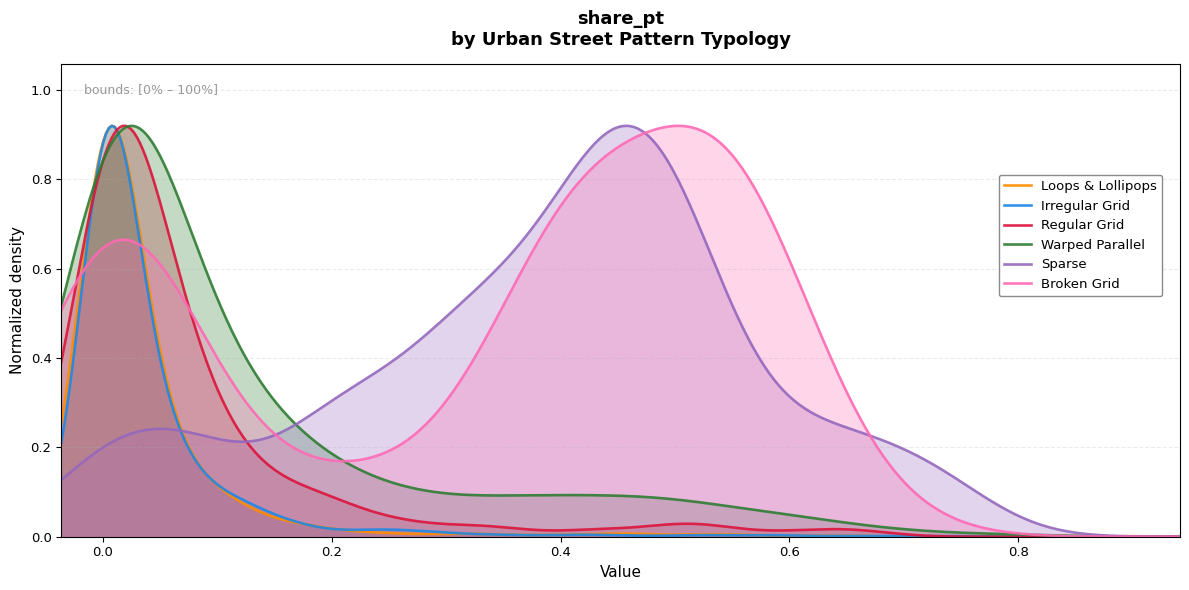

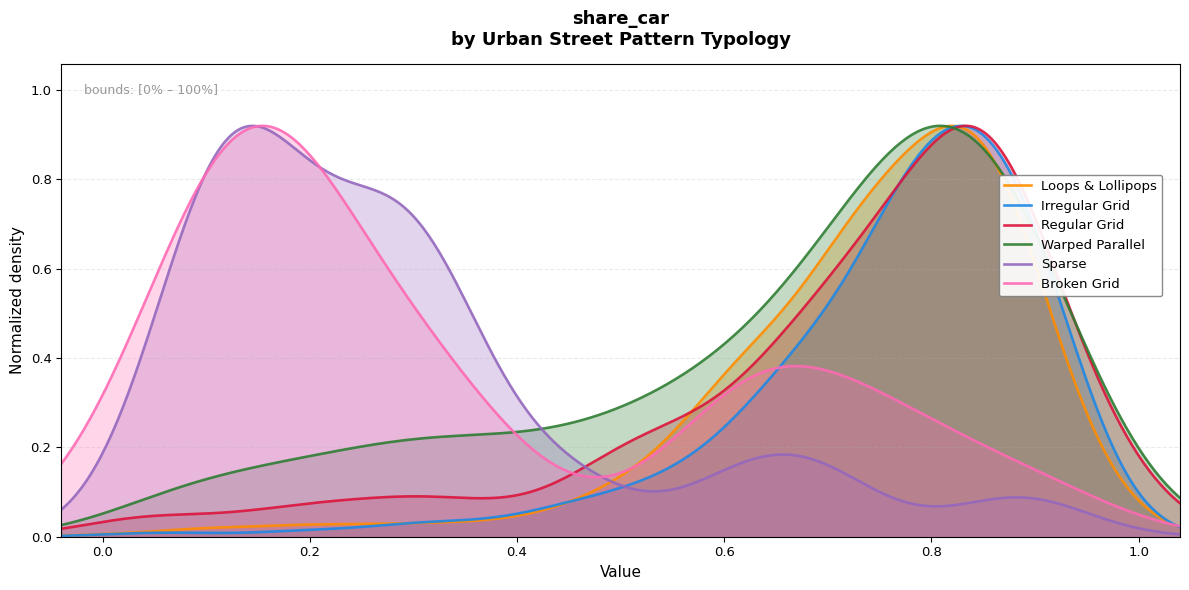

In [42]:
feature_columns = ["share_pt", "share_car"]

class_names = ["Loops & Lollipops", "Irregular Grid", "Regular Grid", "Warped Parallel", "Sparse", "Broken Grid"]



create_overlaid_kde_plots_with_stats(
    gdf,
    feature_columns,
    class_names=class_names,
    figsize=(12, 6),
    min_samples=5,
    lower_percentile=0.00,
    upper_percentile=1.00,
    bw_method=0.3,
    stats_position=(0.98, 0.98),          # можно сдвинуть, напр. (0.98, 0.65)
    stats_fontsize=9.0,
)

In [16]:
gdf.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
  

In [46]:
df["prediction"].describe()

count     8118
unique       6
top          3
freq      4062
Name: prediction, dtype: int64

In [36]:
df.describe()

,area
count,8.160000e+03
mean,7.074592e+06
std,6.858760e+06
min,1.232406e+05
25%,2.102095e+06
50%,4.916724e+06
75%,9.882492e+06
max,3.180622e+07


In [47]:
df = df.dropna(subset="prediction")

In [ ]:
df_copy = df.copy()
df = df_copy.copy()

In [48]:
len(df)

8118

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


# gdf = gdf.dropna(subset="prob_0")
# Определяем признаки (6 вероятностей) и целевые переменные (2 нормализованные колонки)
X = gdf[['prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4', 'prob_5']]
y = gdf[["share_pt", "share_car"]]

# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train размер: {X_train.shape}")
print(f"Test размер: {X_test.shape}")

Train размер: (6494, 6)
Test размер: (1624, 6)


In [37]:
y.describe()

,share_pt,share_car
count,8118.000000,8118.000000
mean,0.084647,0.697003
std,0.143446,0.208854
min,0.000000,0.000000
25%,0.000000,0.615978
50%,0.022533,0.760195
75%,0.090920,0.844522
max,0.905093,1.000000


In [38]:
X.describe()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5
count,8118.0,8118.0,8118.000000,8118.000000,8118.000000,8118.0
unique,8084.0,8112.0,8118.000000,8114.000000,8117.000000,8117.0
top,1.0,1.0,0.000296,0.628697,0.137096,0.0
freq,19.0,6.0,1.000000,2.000000,2.000000,2.0


In [39]:
def approach_1_linear_models():
    """Линейная регрессия с регуляризацией"""
    
    # Обучаем отдельные модели для каждой целевой переменной
    models = {}
    predictions = {}
    
    for target in ["share_pt", "share_car"]:
        # Используем Ridge регрессию
        model = Ridge(alpha=1.0, random_state=42)
        model.fit(X_train, y_train[target])
        models[target] = model
        
        # Предсказания
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
        predictions[target] = {'train': pred_train, 'test': pred_test}
    
    return models, predictions

# Оценка
models1, pred1 = approach_1_linear_models()

print("=== Подход 1: Линейная регрессия (Ridge) ===")
for target in ["share_pt", "share_car"]:
    mse_test = mean_squared_error(y_test[target], pred1[target]['test'])
    mae_test = mean_absolute_error(y_test[target], pred1[target]['test'])
    r2_test = r2_score(y_test[target], pred1[target]['test'])
    print(f"\n{target}:")
    print(f"  MSE: {mse_test:.4f}")
    print(f"  MAE: {mae_test:.4f}")
    print(f"  R²: {r2_test:.4f}")

=== Подход 1: Линейная регрессия (Ridge) ===

share_pt:
  MSE: 0.0134
  MAE: 0.0767
  R²: 0.3914

share_car:
  MSE: 0.0311
  MAE: 0.1364
  R²: 0.3144


In [40]:
def approach_2_random_forest():
    """Случайный лес"""
    
    models = {}
    predictions = {}
    
    for target in ["share_pt", "share_car"]:
        model = RandomForestRegressor(
            n_estimators=100, 
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train[target])
        models[target] = model
        
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
        predictions[target] = {'train': pred_train, 'test': pred_test}
        
        # Важность признаков
        print(f"\nВажность признаков для {target}:")
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        print(feature_importance)
    
    return models, predictions

# Оценка
models2, pred2 = approach_2_random_forest()

print("\n=== Подход 2: Случайный лес ===")
for target in ["share_pt", "share_car"]:
    mse_test = mean_squared_error(y_test[target], pred2[target]['test'])
    mae_test = mean_absolute_error(y_test[target], pred2[target]['test'])
    r2_test = r2_score(y_test[target], pred2[target]['test'])
    print(f"\n{target}:")
    print(f"  MSE: {mse_test:.4f}")
    print(f"  MAE: {mae_test:.4f}")
    print(f"  R²: {r2_test:.4f}")


Важность признаков для share_pt:
  feature  importance
5  prob_5    0.313033
4  prob_4    0.277216
2  prob_2    0.135748
1  prob_1    0.113650
3  prob_3    0.089855
0  prob_0    0.070497

Важность признаков для share_car:
  feature  importance
5  prob_5    0.308859
4  prob_4    0.286711
2  prob_2    0.134057
1  prob_1    0.120362
3  prob_3    0.083044
0  prob_0    0.066966

=== Подход 2: Случайный лес ===

share_pt:
  MSE: 0.0094
  MAE: 0.0616
  R²: 0.5732

share_car:
  MSE: 0.0253
  MAE: 0.1225
  R²: 0.4411


In [41]:
def approach_3_gradient_boosting():
    """Градиентный бустинг"""
    
    models = {}
    predictions = {}
    
    for target in ["share_pt", "share_car"]:
        model = GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
        )
        model.fit(X_train, y_train[target])
        models[target] = model
        
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)
        predictions[target] = {'train': pred_train, 'test': pred_test}
    
    return models, predictions

# Оценка
models3, pred3 = approach_3_gradient_boosting()

print("\n=== Подход 3: Градиентный бустинг ===")
for target in ["share_pt", "share_car"]:
    mse_test = mean_squared_error(y_test[target], pred3[target]['test'])
    mae_test = mean_absolute_error(y_test[target], pred3[target]['test'])
    r2_test = r2_score(y_test[target], pred3[target]['test'])
    print(f"\n{target}:")
    print(f"  MSE: {mse_test:.4f}")
    print(f"  MAE: {mae_test:.4f}")
    print(f"  R²: {r2_test:.4f}")


=== Подход 3: Градиентный бустинг ===

share_pt:
  MSE: 0.0095
  MAE: 0.0623
  R²: 0.5669

share_car:
  MSE: 0.0259
  MAE: 0.1236
  R²: 0.4290


In [ ]:
df.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Нормализуем последние две колонки
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Public_transport_total', 'Public_transport_bus']] = scaler.fit_transform(
    df[['Estimate!!Total:!!Public transportation:', 
        'Estimate!!Total:!!Public transportation:!!Bus']]
)


print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (8118, 32)

Первые 5 строк:


,Geography,Geographic Area Name,Estimate!!Total:,"Estimate!!Total:!!Car, truck, or van:","Estimate!!Total:!!Car, truck, or van:!!Drove alone","Estimate!!Total:!!Car, truck, or van:!!Carpooled:","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool","Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool",Estimate!!Total:!!Public transportation:,...,graph,prediction,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,Public_transport_total,Public_transport_bus
51206,1400000US36047050803,Census Tract 508.03; Kings County; New York,1459,204,204,0,0,0,0,912,...,"(4867, 4807, 4713, 4688, 4953)",3,0.083915,0.063253,0.125659,0.345287,0.245426,0.136459,0.271752,0.000000
50821,1400000US36047009201,Census Tract 92.01; Kings County; New York,1076,310,164,146,146,0,0,460,...,"(1432, 1482, 1383)",0,0.299275,0.212381,0.123899,0.144606,0.142155,0.077684,0.137068,0.056903
51375,1400000US36047079001,Census Tract 790.01; Kings County; New York,576,172,172,0,0,0,0,312,...,"(5634, 5573, 5642, 5515, 5618, 5491, 5622, 5593)",3,0.072168,0.077359,0.104345,0.508831,0.165407,0.071889,0.092968,0.072761
50807,1400000US36047007200,Census Tract 72; Kings County; New York,834,188,168,20,11,0,9,508,...,"(388, 390, 490, 427, 428, 400, 401, 468, 406, ...",3,0.021525,0.016663,0.038894,0.741499,0.147427,0.033991,0.151371,0.026119
50973,1400000US36047025902,Census Tract 259.02; Kings County; New York,1165,175,175,0,0,0,0,762,...,"(6547, 6660)",0,0.275414,0.139705,0.108343,0.271236,0.135523,0.069779,0.227056,0.221082


In [ ]:
X = df[['prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4', 'prob_5']]
y = df[['Public_transport_total', 'Public_transport_bus']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train размер: {X_train.shape}")
print(f"Test размер: {X_test.shape}")

Train размер: (6494, 6)
Test размер: (1624, 6)


In [ ]:
corr_matrix = df[['prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4', 'prob_5', 'Public_transport_total', 'Public_transport_bus']].corr(method=)

In [77]:
print(corr_matrix)

                          prob_0    prob_1    prob_2    prob_3    prob_4  \
prob_0                  1.000000 -0.018199 -0.375987 -0.734282 -0.496935   
prob_1                 -0.018199  1.000000 -0.129814 -0.536274 -0.374087   
prob_2                 -0.375987 -0.129814  1.000000  0.055209  0.414696   
prob_3                 -0.734282 -0.536274  0.055209  1.000000  0.365213   
prob_4                 -0.496935 -0.374087  0.414696  0.365213  1.000000   
prob_5                 -0.193848 -0.102168  0.300833 -0.058064  0.469036   
Public_transport_total -0.210732 -0.211041  0.103218  0.187423  0.436427   
Public_transport_bus   -0.205232 -0.168069  0.084882  0.210836  0.294432   

                          prob_5  Public_transport_total  Public_transport_bus  
prob_0                 -0.193848               -0.210732             -0.205232  
prob_1                 -0.102168               -0.211041             -0.168069  
prob_2                  0.300833                0.103218              0.

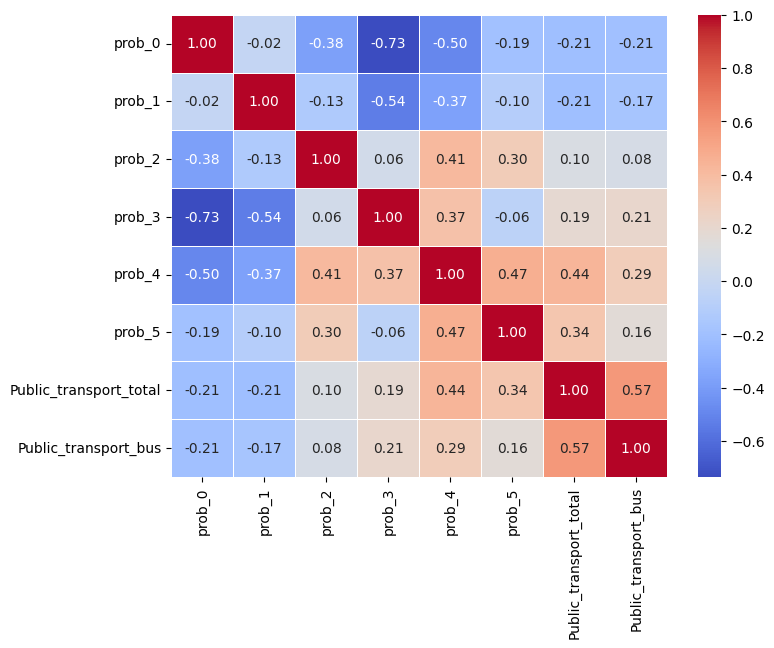

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [91]:
df.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
  

In [89]:
cm = df[['Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
       'Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means',
       'Estimate!!Total:!!Worked from home', 'area',
        'prediction', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4',
       'prob_5',
       'Public_transport_total', 'Public_transport_bus']].corr(method="spearman")

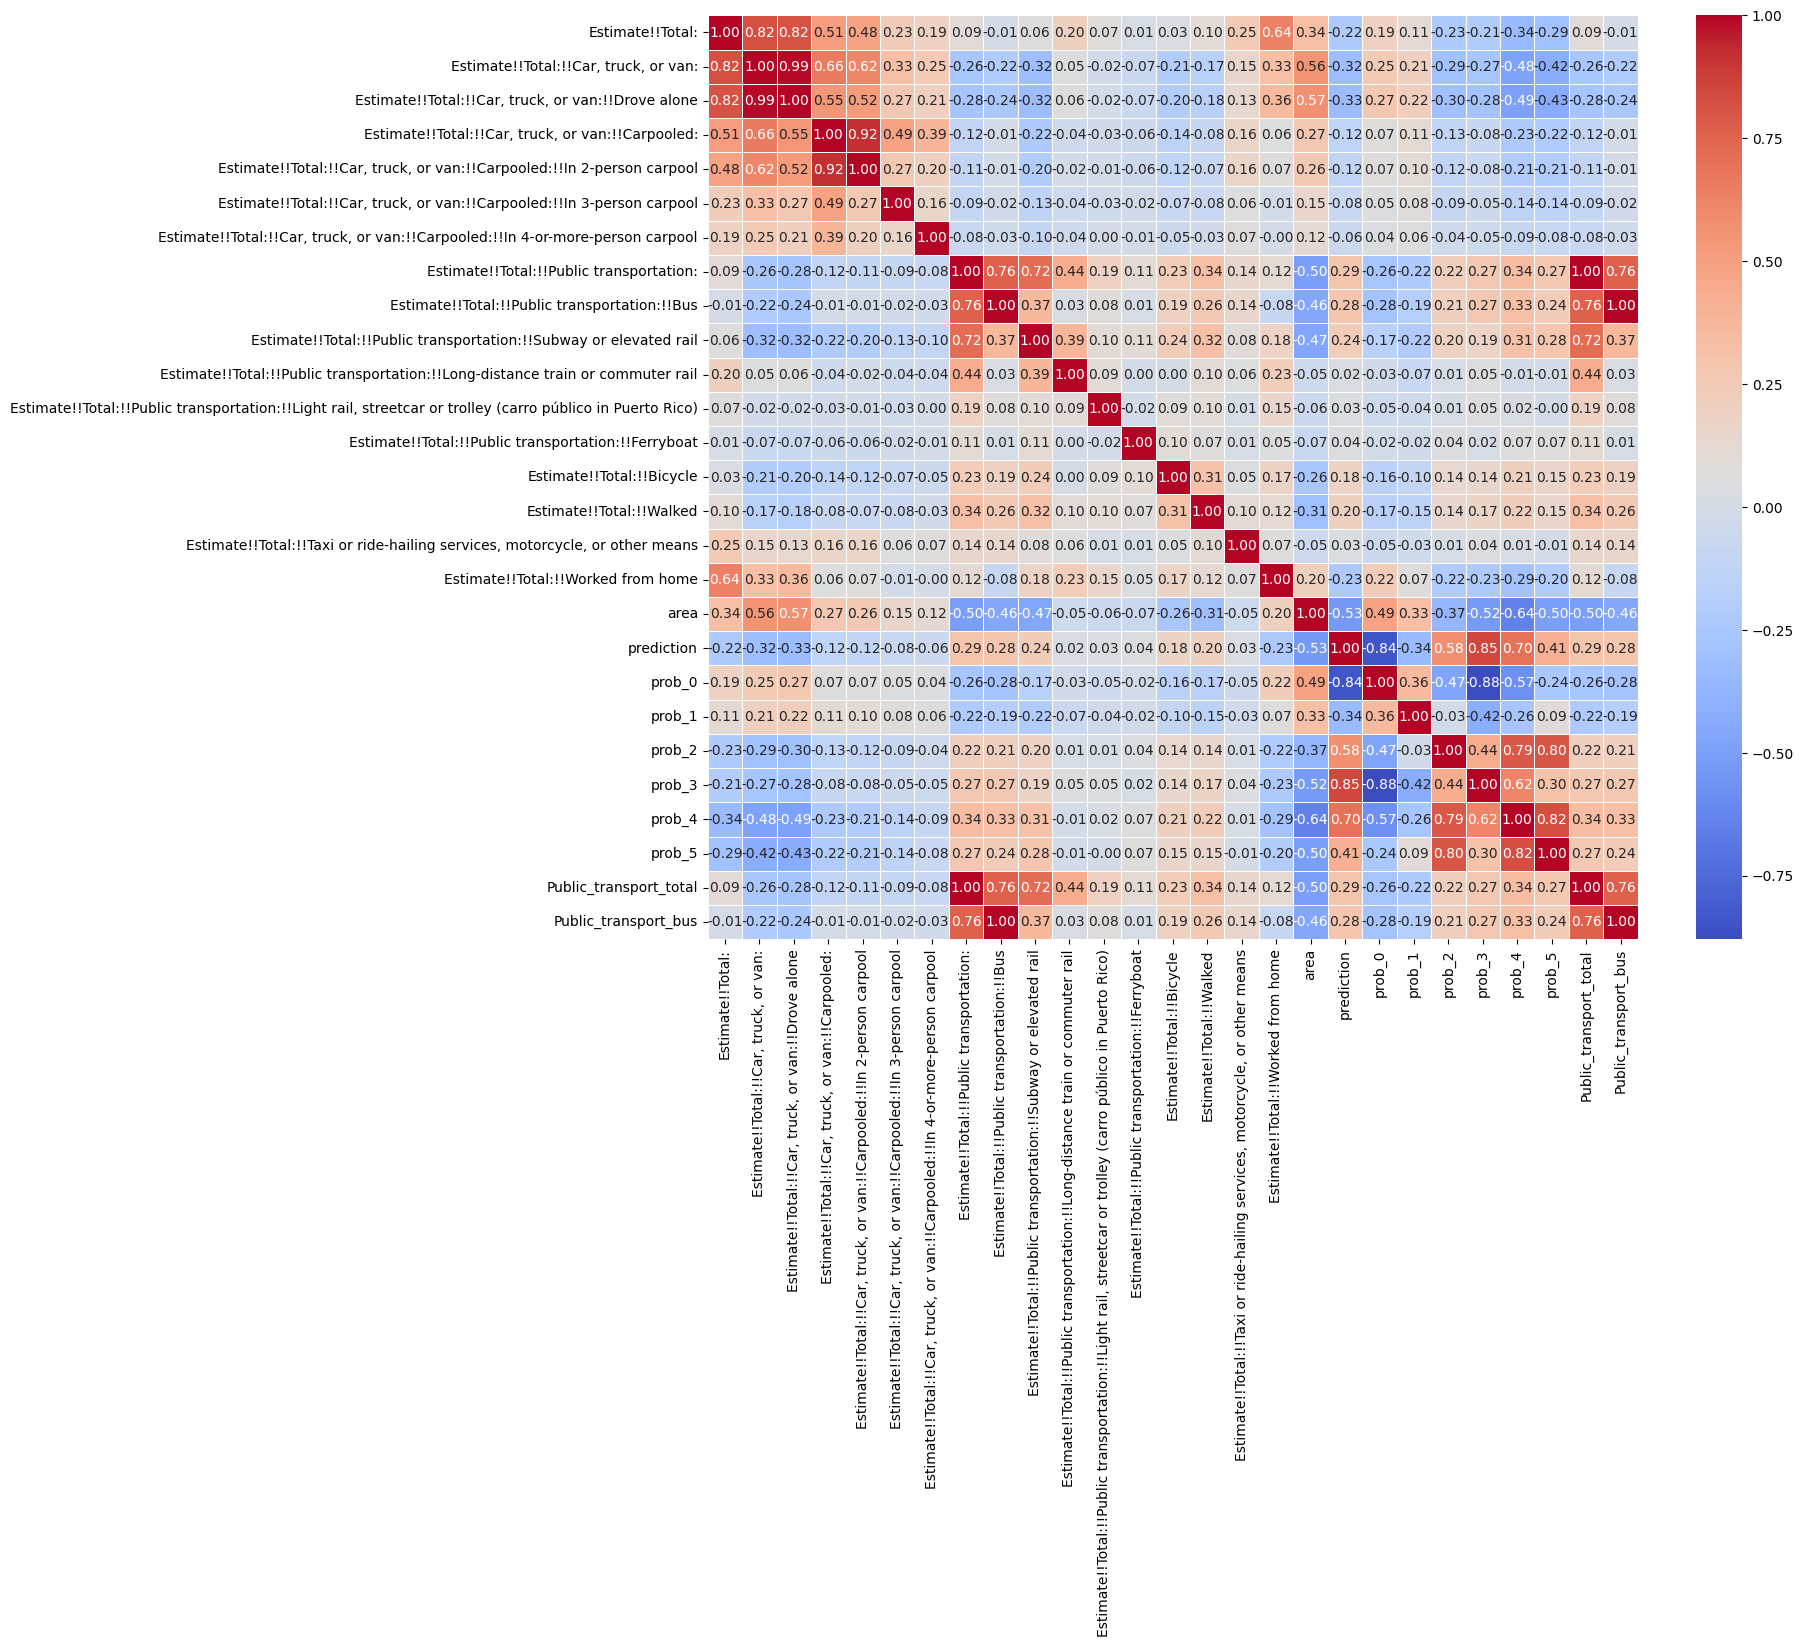

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [124]:
df.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
  

In [95]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ==============================================
# 0. ПРЕОБРАЗОВАНИЕ ТИПОВ ДАННЫХ
# ==============================================
print("=" * 60)
print("0. Проверка и преобразование типов данных")
print("=" * 60)

# Создаем копию DataFrame для результатов
df_normalized = df.copy()

# Список колонок для нормализации
cols_to_normalize = [
    'Estimate!!Total:',
    'Estimate!!Total:!!Car, truck, or van:',
    'Estimate!!Total:!!Public transportation:',
    'Estimate!!Total:!!Public transportation:!!Bus',
    'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
    'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
    'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
    'Estimate!!Total:!!Public transportation:!!Ferryboat',
    'Estimate!!Total:!!Bicycle', 
    'Estimate!!Total:!!Walked',
    'Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means',
    'Estimate!!Total:!!Worked from home'
]

# Проверяем и преобразуем типы данных
for col in cols_to_normalize:
    if col in df_normalized.columns:
        # Если колонка существует, проверяем тип
        if df_normalized[col].dtype == 'object':
            # Пытаемся преобразовать в numeric, заменяя некорректные значения на NaN
            df_normalized[col] = pd.to_numeric(df_normalized[col], errors='coerce')
            print(f"Преобразована колонка '{col}': {df_normalized[col].dtype}")
        else:
            print(f"Колонка '{col}' уже имеет тип {df_normalized[col].dtype}")
    else:
        print(f"Предупреждение: колонка '{col}' не найдена в DataFrame")

# Проверяем наличие пропущенных значений
print("\nПропущенные значения после преобразования:")
for col in cols_to_normalize:
    if col in df_normalized.columns:
        missing = df_normalized[col].isna().sum()
        if missing > 0:
            print(f"  {col}: {missing} пропущенных значений")


0. Проверка и преобразование типов данных
Преобразована колонка 'Estimate!!Total:': int64
Преобразована колонка 'Estimate!!Total:!!Car, truck, or van:': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:!!Bus': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:!!Subway or elevated rail': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)': int64
Преобразована колонка 'Estimate!!Total:!!Public transportation:!!Ferryboat': int64
Преобразована колонка 'Estimate!!Total:!!Bicycle': int64
Преобразована колонка 'Estimate!!Total:!!Walked': int64
Преобразована колонка 'Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means': int64
Преобразована колонка 'Estimate!!Total:!!Work

In [100]:

# ==============================================
# 1. НОРМАЛИЗАЦИЯ ОТНОСИТЕЛЬНО TOTAL (Доли)
# ==============================================
print("\n" + "=" * 60)
print("1. Нормализация относительно Total (проценты от населения)")
print("=" * 60)

# Получаем общую численность
total_pop = df_normalized['Estimate!!Total:']

# Исключаем саму Total из списка для нормализации
cols_for_normalization = [col for col in cols_to_normalize if col != 'Estimate!!Total:']

# Нормализуем каждую колонку относительно Total
for col in cols_for_normalization:
    if col in df_normalized.columns:
        # Проверяем, что total_pop не содержит NaN и не равен 0
        valid_mask = (total_pop.notna()) & (total_pop > 0)
        
        # Создаем новую колонку с процентами
        new_col_name = f'pct_of_total_{col.replace("Estimate!!Total:!!", "").replace(":", "_").replace(" ", "_")}'
        df_normalized[new_col_name] = np.nan  # Инициализируем NaN
        
        # Вычисляем проценты только для валидных строк
        df_normalized.loc[valid_mask, new_col_name] = (df_normalized.loc[valid_mask, col] / 
                                                        total_pop.loc[valid_mask])
        
        # Выводим статистику для проверки
        print(f"\n{new_col_name}:")
        print(f"  Диапазон: [{df_normalized[new_col_name].min():.2f}, {df_normalized[new_col_name].max():.2f}]")
        print(f"  Среднее: {df_normalized[new_col_name].mean():.2f}")
        print(f"  Медиана: {df_normalized[new_col_name].median():.2f}")
        print(f"  Пропущенные значения: {df_normalized[new_col_name].isna().sum()}")



1. Нормализация относительно Total (проценты от населения)

pct_of_total_Car,_truck,_or_van_:
  Диапазон: [0.00, 1.00]
  Среднее: 0.70
  Медиана: 0.76
  Пропущенные значения: 0

pct_of_total_Public_transportation_:
  Диапазон: [0.00, 0.91]
  Среднее: 0.08
  Медиана: 0.02
  Пропущенные значения: 0

pct_of_total_Public_transportation_!!Bus:
  Диапазон: [0.00, 0.57]
  Среднее: 0.03
  Медиана: 0.01
  Пропущенные значения: 0

pct_of_total_Public_transportation_!!Subway_or_elevated_rail:
  Диапазон: [0.00, 0.73]
  Среднее: 0.04
  Медиана: 0.00
  Пропущенные значения: 0

pct_of_total_Public_transportation_!!Long-distance_train_or_commuter_rail:
  Диапазон: [0.00, 0.41]
  Среднее: 0.01
  Медиана: 0.00
  Пропущенные значения: 0

pct_of_total_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico):
  Диапазон: [0.00, 0.17]
  Среднее: 0.00
  Медиана: 0.00
  Пропущенные значения: 0

pct_of_total_Public_transportation_!!Ferryboat:
  Диапазон: [0.00, 0.18]
  Среднее:

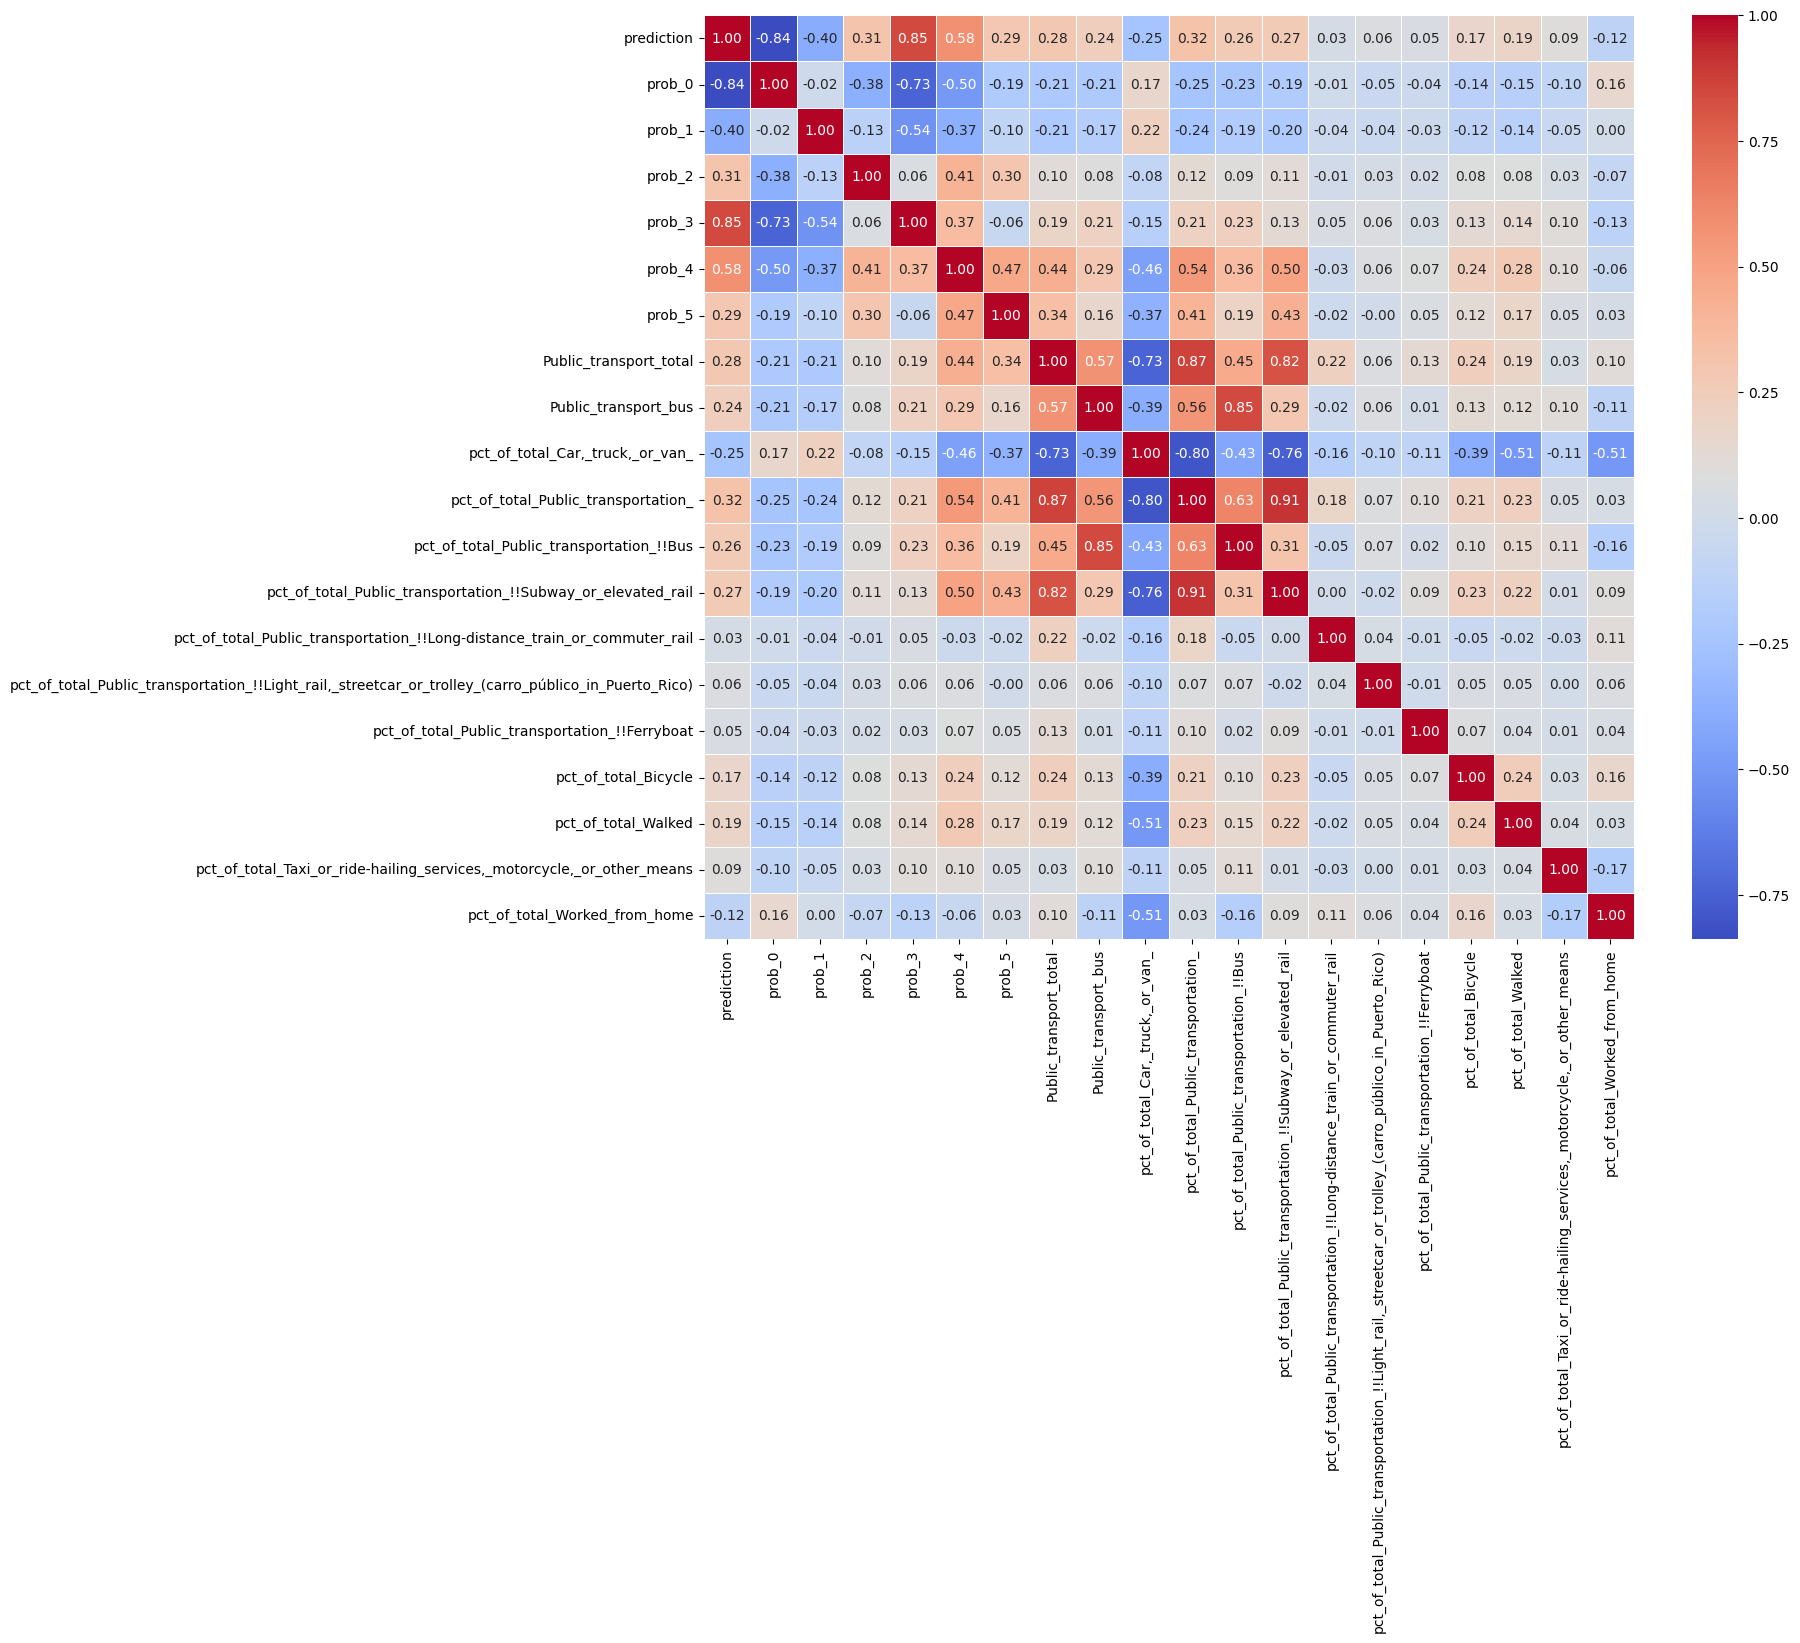

In [ ]:
# df_normalized.columns

cm = df_normalized[[
        'prediction', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4',
       'prob_5', 'Public_transport_total', 'Public_transport_bus',
       'pct_of_total_Car,_truck,_or_van_',
       'pct_of_total_Public_transportation_',
       'pct_of_total_Public_transportation_!!Bus',
       'pct_of_total_Public_transportation_!!Subway_or_elevated_rail',
       'pct_of_total_Public_transportation_!!Long-distance_train_or_commuter_rail',
       'pct_of_total_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico)',
       'pct_of_total_Public_transportation_!!Ferryboat',
       'pct_of_total_Bicycle', 'pct_of_total_Walked',
       'pct_of_total_Taxi_or_ride-hailing_services,_motorcycle,_or_other_means',
       'pct_of_total_Worked_from_home']].corr()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [106]:

# ==============================================
# 2. НОРМАЛИЗАЦИЯ ВНУТРИ ГРУППЫ PUBLIC TRANSPORTATION
# ==============================================
print("\n" + "=" * 60)
print("2. Нормализация внутри Public Transportation (структура пользователей)")
print("=" * 60)

# Список подкатегорий общественного транспорта
public_subcats = [
    'Estimate!!Total:!!Public transportation:!!Bus',
    'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
    'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
    'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
    'Estimate!!Total:!!Public transportation:!!Ferryboat'
]

# Проверяем наличие колонки с общим количеством пользователей транспорта
if 'Estimate!!Total:!!Public transportation:' in df_normalized.columns:
    public_total = df_normalized['Estimate!!Total:!!Public transportation:']
    
    # Нормализуем каждую подкатегорию
    for col in public_subcats:
        if col in df_normalized.columns:
            # Создаем маску для валидных значений (не NaN и > 0)
            valid_mask = (public_total.notna()) & (public_total > 0) & (df_normalized[col].notna())
            
            # Создаем имя для новой колонки
            col_name_clean = col.split('!!')[-1].replace(' ', '_').replace('(', '').replace(')', '').replace(',', '')
            new_col_name = f'share_of_public_{col_name_clean}'
            
            df_normalized[new_col_name] = np.nan
            
            # Вычисляем доли
            df_normalized.loc[valid_mask, new_col_name] = (df_normalized.loc[valid_mask, col] / 
                                                            public_total.loc[valid_mask]) * 100
            
            print(f"\n{new_col_name}:")
            if valid_mask.any():
                print(f"  Диапазон: [{df_normalized.loc[valid_mask, new_col_name].min():.2f}%, {df_normalized.loc[valid_mask, new_col_name].max():.2f}%]")
                print(f"  Среднее (среди пользующихся): {df_normalized.loc[valid_mask, new_col_name].mean():.2f}%")
            else:
                print("  Нет валидных данных для расчета")
else:
    print("Колонка 'Estimate!!Total:!!Public transportation:' не найдена")



2. Нормализация внутри Public Transportation (структура пользователей)

share_of_public_Bus:
  Диапазон: [0.00%, 100.00%]
  Среднее (среди пользующихся): 58.68%

share_of_public_Subway_or_elevated_rail:
  Диапазон: [0.00%, 100.00%]
  Среднее (среди пользующихся): 21.01%

share_of_public_Long-distance_train_or_commuter_rail:
  Диапазон: [0.00%, 100.00%]
  Среднее (среди пользующихся): 16.28%

share_of_public_Light_rail_streetcar_or_trolley_carro_público_in_Puerto_Rico:
  Диапазон: [0.00%, 100.00%]
  Среднее (среди пользующихся): 3.28%

share_of_public_Ferryboat:
  Диапазон: [0.00%, 100.00%]
  Среднее (среди пользующихся): 0.75%


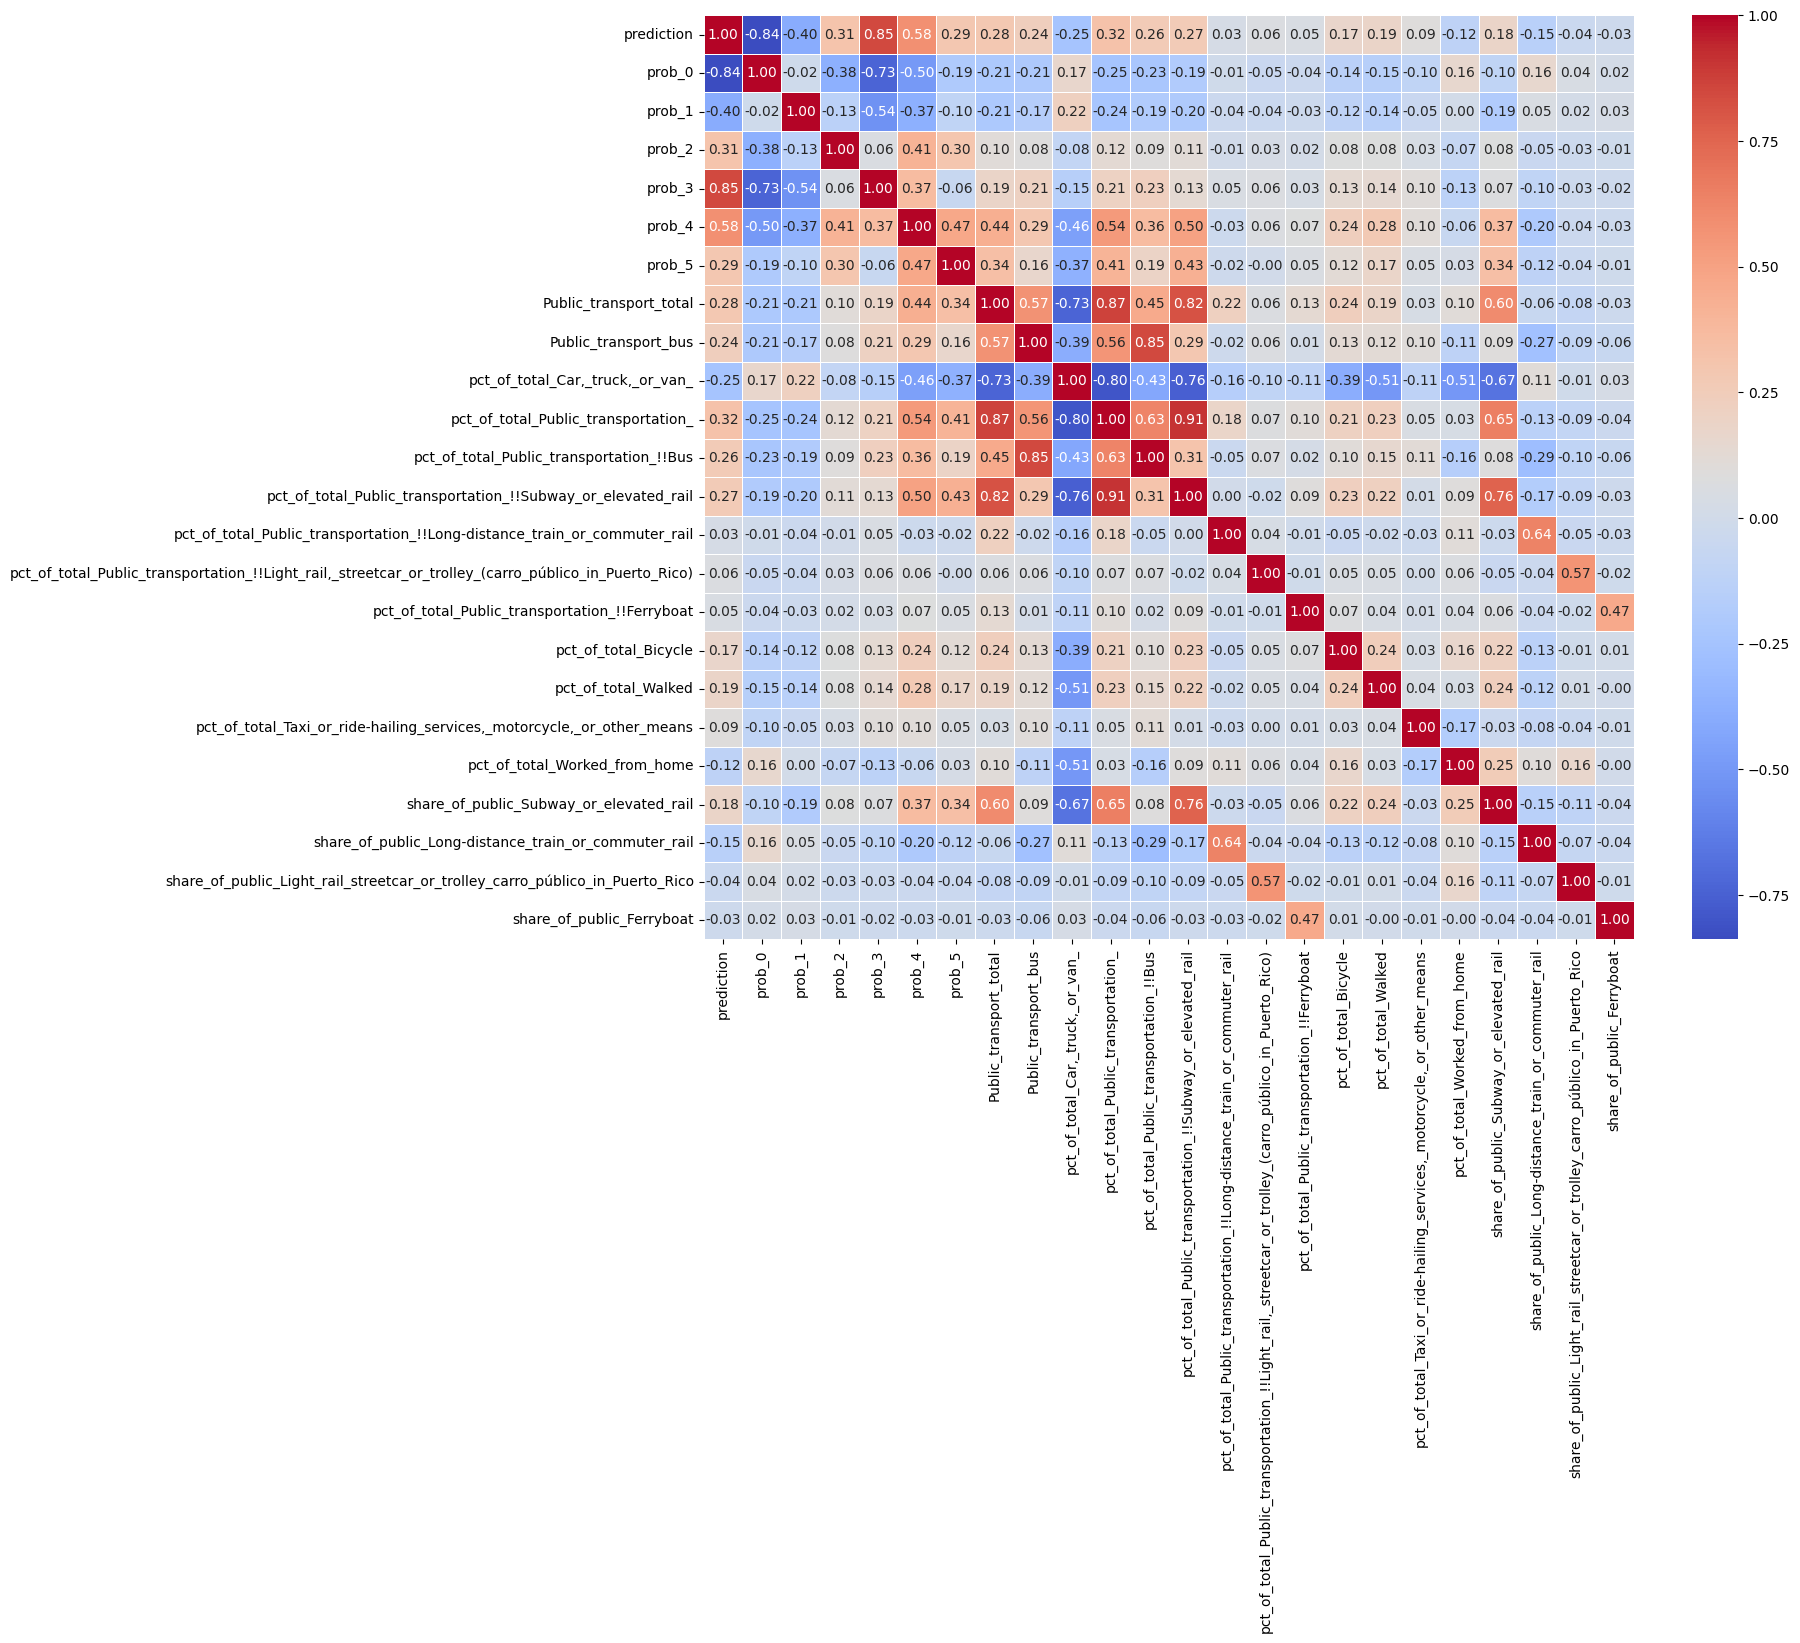

In [109]:
# df_normalized.columns


cm = df_normalized[[
        'prediction', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4',
       'prob_5', 'Public_transport_total', 'Public_transport_bus',
       'pct_of_total_Car,_truck,_or_van_',
       'pct_of_total_Public_transportation_',
       'pct_of_total_Public_transportation_!!Bus',
       'pct_of_total_Public_transportation_!!Subway_or_elevated_rail',
       'pct_of_total_Public_transportation_!!Long-distance_train_or_commuter_rail',
       'pct_of_total_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico)',
       'pct_of_total_Public_transportation_!!Ferryboat',
       'pct_of_total_Bicycle', 'pct_of_total_Walked',
       'pct_of_total_Taxi_or_ride-hailing_services,_motorcycle,_or_other_means',
       'pct_of_total_Worked_from_home',
       'share_of_public_Subway_or_elevated_rail',
       'share_of_public_Long-distance_train_or_commuter_rail',
       'share_of_public_Light_rail_streetcar_or_trolley_carro_público_in_Puerto_Rico',
       'share_of_public_Ferryboat']].corr()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [110]:

# ==============================================
# 3. ЛОГАРИФМИЧЕСКОЕ ПРЕОБРАЗОВАНИЕ (Log1p)
# ==============================================
print("\n" + "=" * 60)
print("3. Логарифмическое преобразование (для работы с выбросами)")
print("=" * 60)

# Применяем log1p к абсолютным значениям (исключая Total)
for col in cols_for_normalization:
    if col in df_normalized.columns and col != 'Estimate!!Total:':
        col_name_clean = col.replace("Estimate!!Total:!!", "").replace(":", "_").replace(" ", "_")
        new_col_name = f'log_{col_name_clean}'
        
        # log1p обрабатывает нули и пропуски корректно
        df_normalized[new_col_name] = np.log1p(df_normalized[col].fillna(0))
        
        print(f"\n{new_col_name}:")
        print(f"  Диапазон: [{df_normalized[new_col_name].min():.3f}, {df_normalized[new_col_name].max():.3f}]")
        if not df_normalized[col].isna().all():
            print(f"  Асимметрия до: {df_normalized[col].skew():.3f}")
            print(f"  Асимметрия после: {df_normalized[new_col_name].skew():.3f}")


3. Логарифмическое преобразование (для работы с выбросами)

log_Car,_truck,_or_van_:
  Диапазон: [0.000, 8.706]
  Асимметрия до: 0.695
  Асимметрия после: -1.725

log_Public_transportation_:
  Диапазон: [0.000, 8.119]
  Асимметрия до: 3.344
  Асимметрия после: -0.236

log_Public_transportation_!!Bus:
  Диапазон: [0.000, 6.978]
  Асимметрия до: 3.277
  Асимметрия после: 0.045

log_Public_transportation_!!Subway_or_elevated_rail:
  Диапазон: [0.000, 7.985]
  Асимметрия до: 4.599
  Асимметрия после: 1.258

log_Public_transportation_!!Long-distance_train_or_commuter_rail:
  Диапазон: [0.000, 6.596]
  Асимметрия до: 5.168
  Асимметрия после: 1.604

log_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico):
  Диапазон: [0.000, 5.714]
  Асимметрия до: 9.909
  Асимметрия после: 3.889

log_Public_transportation_!!Ferryboat:
  Диапазон: [0.000, 6.509]
  Асимметрия до: 41.278
  Асимметрия после: 8.379

log_Bicycle:
  Диапазон: [0.000, 6.450]
  Асимметрия до: 6.0

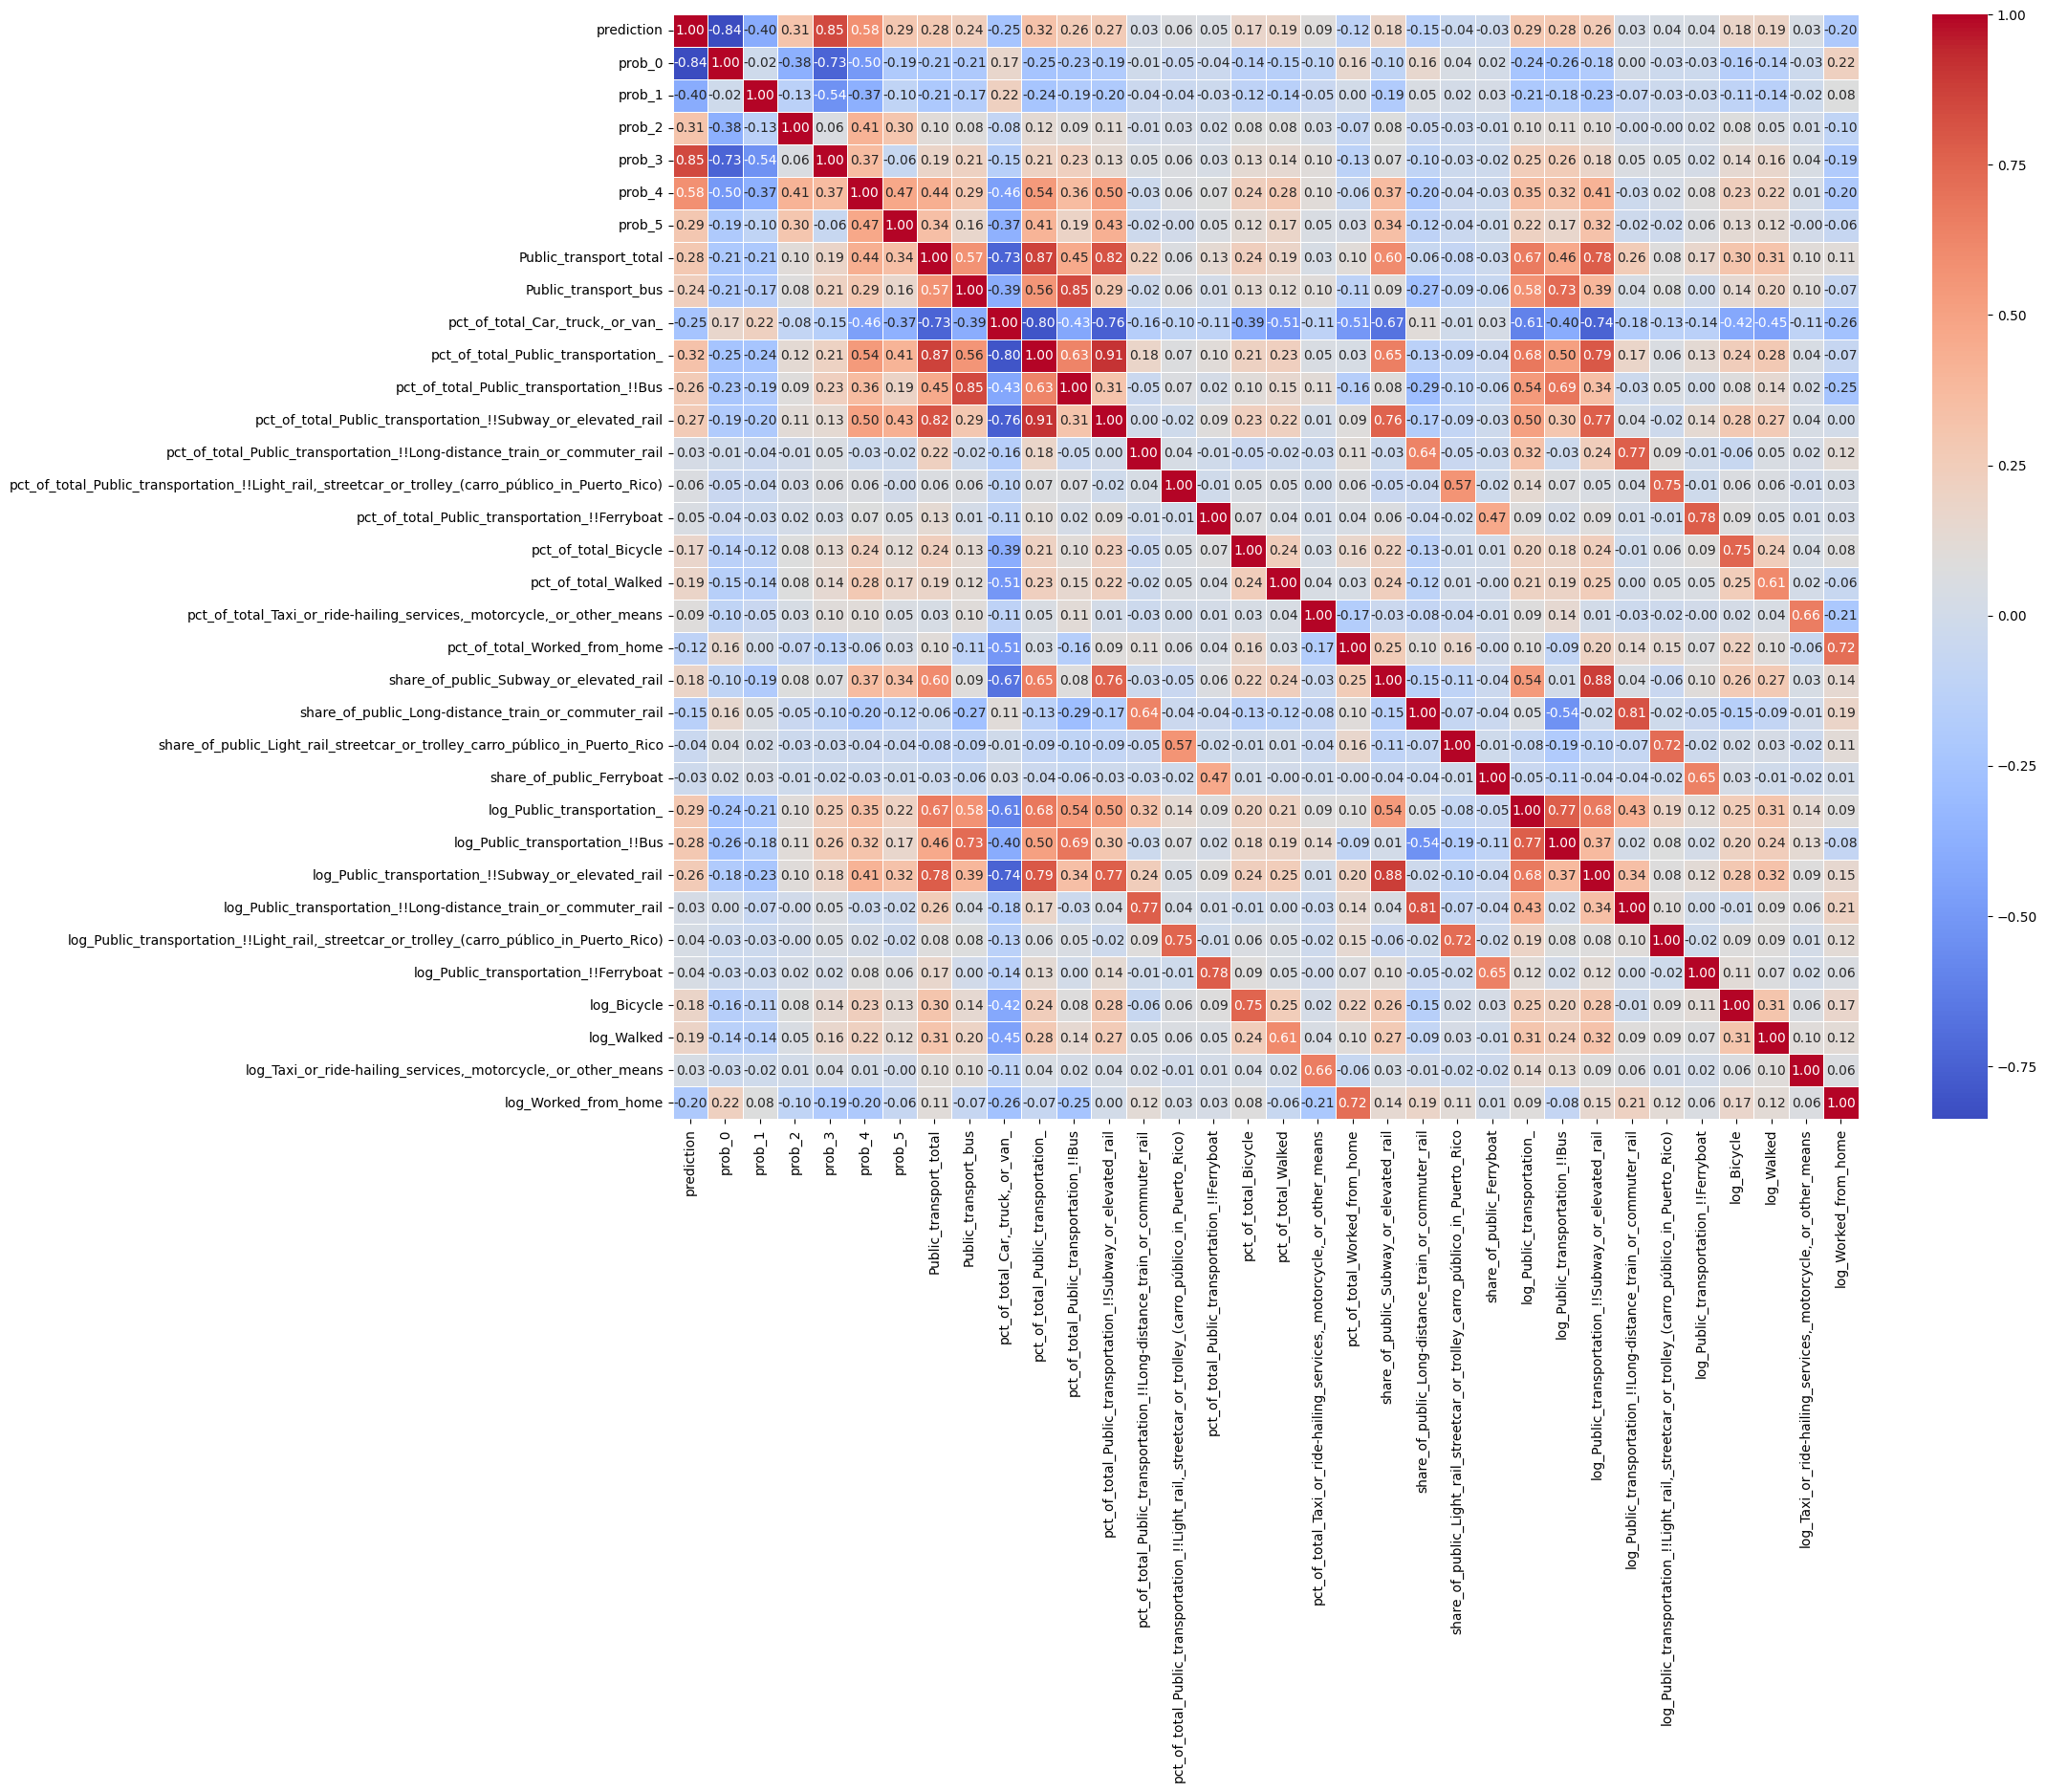

In [113]:
# df_normalized.columns


cm = df_normalized[[
        'prediction', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4',
       'prob_5', 'Public_transport_total', 'Public_transport_bus',
       'pct_of_total_Car,_truck,_or_van_',
       'pct_of_total_Public_transportation_',
       'pct_of_total_Public_transportation_!!Bus',
       'pct_of_total_Public_transportation_!!Subway_or_elevated_rail',
       'pct_of_total_Public_transportation_!!Long-distance_train_or_commuter_rail',
       'pct_of_total_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico)',
       'pct_of_total_Public_transportation_!!Ferryboat',
       'pct_of_total_Bicycle', 'pct_of_total_Walked',
       'pct_of_total_Taxi_or_ride-hailing_services,_motorcycle,_or_other_means',
       'pct_of_total_Worked_from_home',
       'share_of_public_Subway_or_elevated_rail',
       'share_of_public_Long-distance_train_or_commuter_rail',
       'share_of_public_Light_rail_streetcar_or_trolley_carro_público_in_Puerto_Rico',
       'share_of_public_Ferryboat',
       'log_Public_transportation_', 'log_Public_transportation_!!Bus',
       'log_Public_transportation_!!Subway_or_elevated_rail',
       'log_Public_transportation_!!Long-distance_train_or_commuter_rail',
       'log_Public_transportation_!!Light_rail,_streetcar_or_trolley_(carro_público_in_Puerto_Rico)',
       'log_Public_transportation_!!Ferryboat', 'log_Bicycle', 'log_Walked',
       'log_Taxi_or_ride-hailing_services,_motorcycle,_or_other_means',
       'log_Worked_from_home']].corr()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [114]:


# ==============================================
# 4. МАСШТАБИРОВАНИЕ ДЛЯ МАШИННОГО ОБУЧЕНИЯ
# ==============================================
print("\n" + "=" * 60)
print("4. Масштабирование для ML (MinMaxScaler, StandardScaler)")
print("=" * 60)

# Выбираем колонки с процентами для масштабирования
pct_cols = [col for col in df_normalized.columns if col.startswith('pct_of_total_')]

if pct_cols:
    # Убираем строки с NaN для масштабирования
    scaler_df = df_normalized[pct_cols].copy()
    
    # Заполняем NaN нулями для масштабирования
    scaler_df_filled = scaler_df.fillna(0)
    
    # MinMaxScaler (диапазон [0, 1])
    minmax_scaler = MinMaxScaler()
    minmax_scaled = minmax_scaler.fit_transform(scaler_df_filled)
    for i, col in enumerate(pct_cols):
        df_normalized[f'minmax_{col}'] = minmax_scaled[:, i]
    
    # StandardScaler (среднее 0, std 1)
    std_scaler = StandardScaler()
    std_scaled = std_scaler.fit_transform(scaler_df_filled)
    for i, col in enumerate(pct_cols):
        df_normalized[f'standard_{col}'] = std_scaled[:, i]
    
    print(f"\nМасштабировано {len(pct_cols)} колонок:")
    print("  - MinMaxScaler: диапазон [0, 1]")
    print("  - StandardScaler: среднее 0, std 1")
    
    # Показываем пример
    example_cols = ['area'] + [col for col in df_normalized.columns if col.startswith('minmax_pct_of_total_')][:3]
    print("\nПример масштабированных данных:")
    print(df_normalized[example_cols].head())
else:
    print("  Нет колонок с процентами для масштабирования")



4. Масштабирование для ML (MinMaxScaler, StandardScaler)

Масштабировано 11 колонок:
  - MinMaxScaler: диапазон [0, 1]
  - StandardScaler: среднее 0, std 1

Пример масштабированных данных:
                area  minmax_pct_of_total_Car,_truck,_or_van_  \
51206  123240.583333                                 0.139822   
50821  124226.085773                                 0.288104   
51375  130693.043328                                 0.298611   
50807  130839.755679                                 0.225420   
50973  131181.465934                                 0.150215   

       minmax_pct_of_total_Public_transportation_  \
51206                                    0.690632   
50821                                    0.472338   
51375                                    0.598465   
50807                                    0.672984   
50973                                    0.722663   

       minmax_pct_of_total_Public_transportation_!!Bus  
51206                                      

In [116]:
df_normalized.columns

Index(['Geography', 'Geographic Area Name', 'Estimate!!Total:',
       'Estimate!!Total:!!Car, truck, or van:',
       'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
       'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
       'Estimate!!Total:!!Public transportation:',
       'Estimate!!Total:!!Public transportation:!!Bus',
       'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
       'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
       'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
       'Estimate!!Total:!!Public transportation:!!Ferryboat',
       'Estimate!!Total:!!Bicycle', 'Estimate!!Total:!!Walked',
  

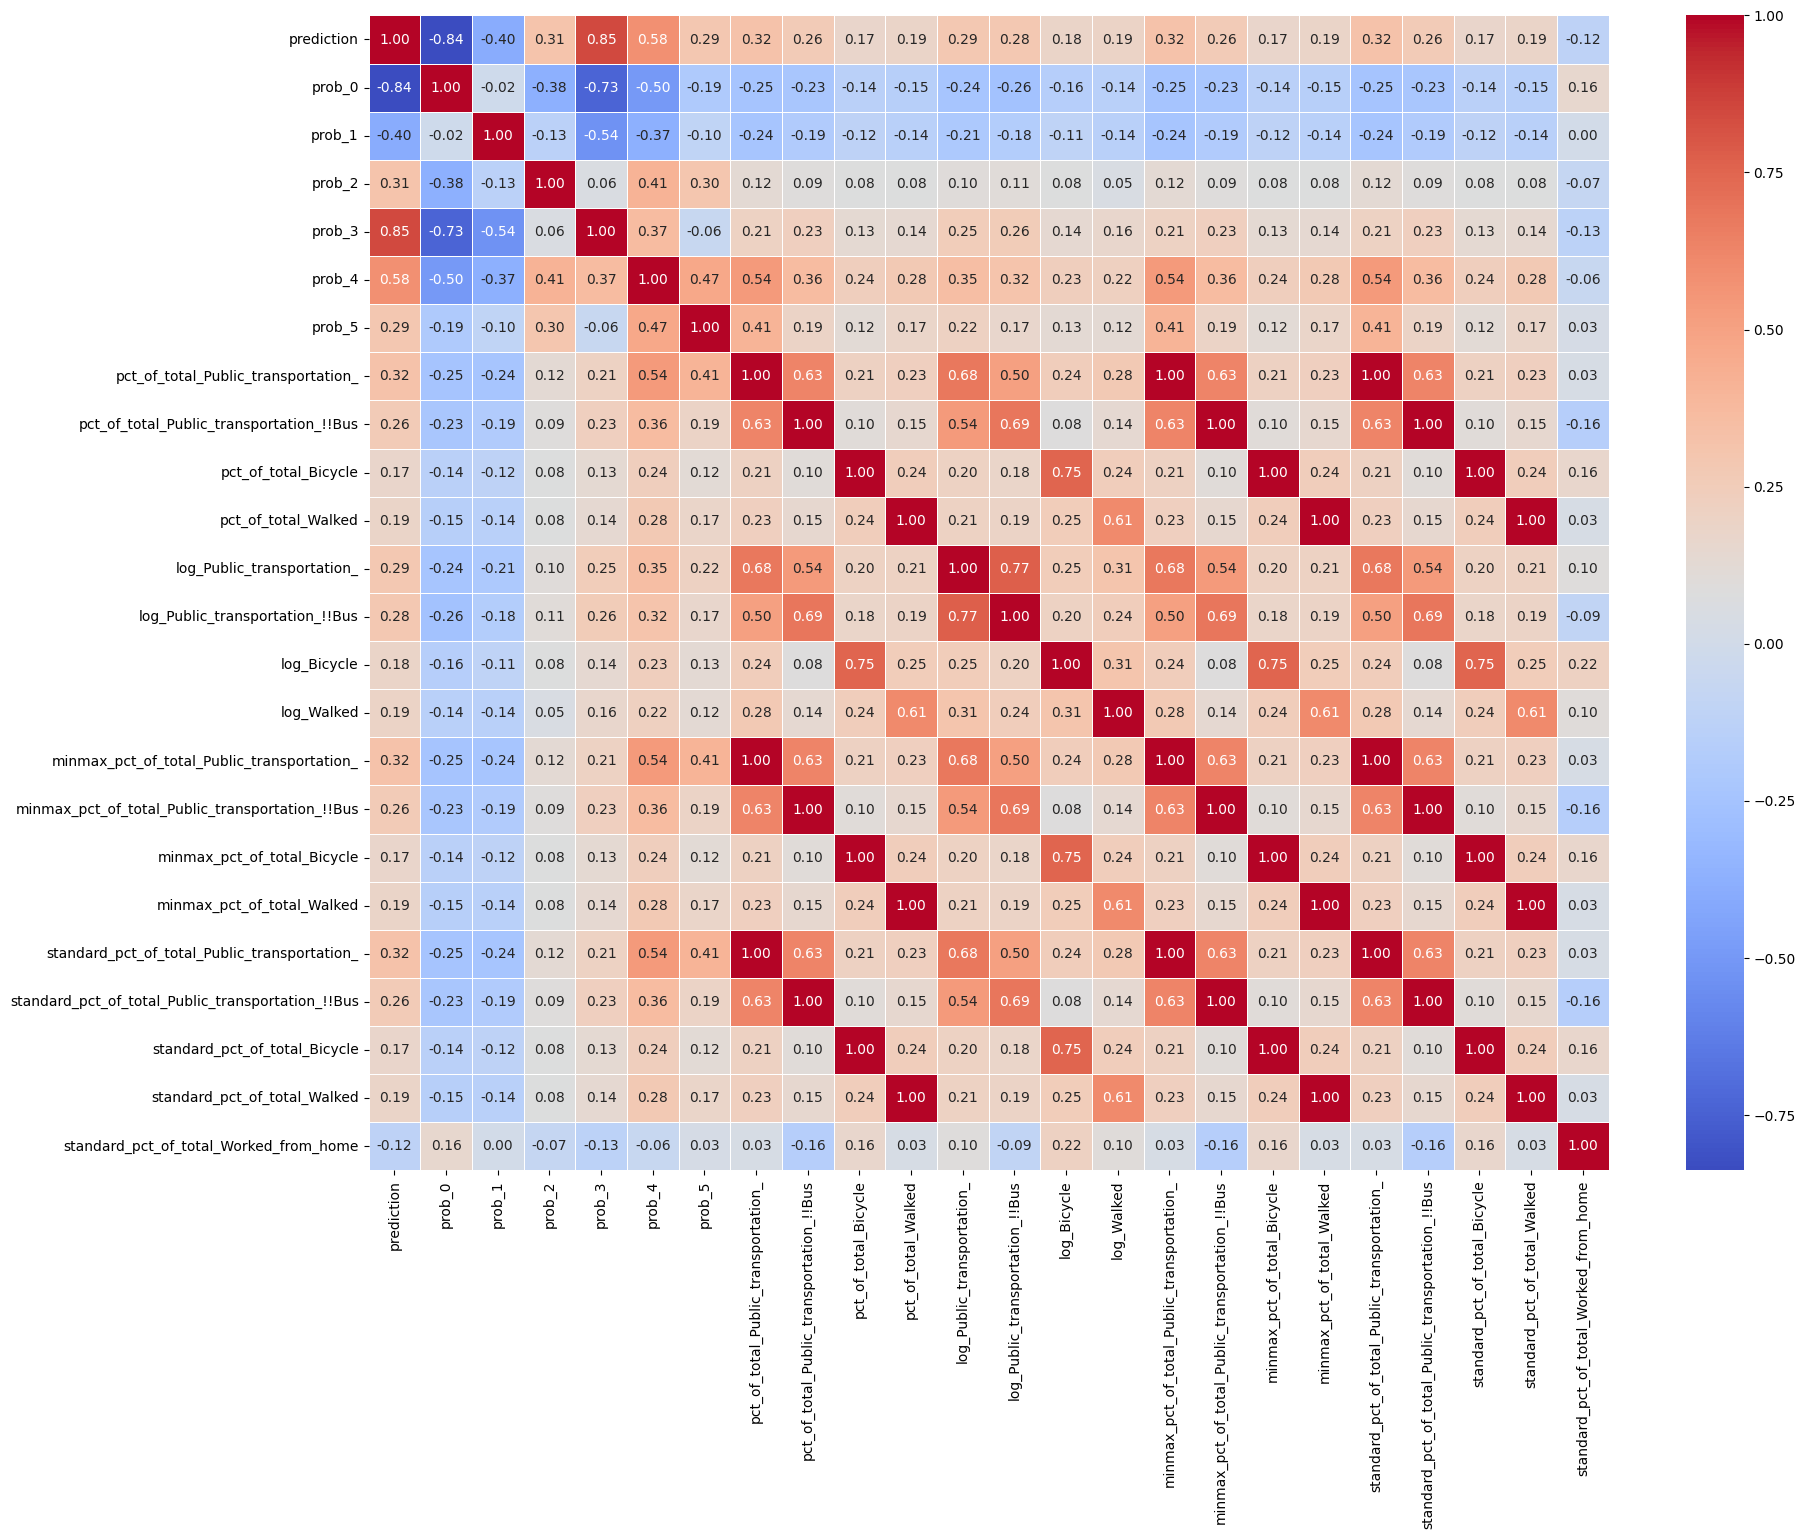

In [123]:
cm = df_normalized[[
        'prediction', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'prob_4',
       'prob_5', 
       'pct_of_total_Public_transportation_',
       'pct_of_total_Public_transportation_!!Bus',
       'pct_of_total_Bicycle', 'pct_of_total_Walked',
       'log_Public_transportation_', 'log_Public_transportation_!!Bus',
       'log_Bicycle', 'log_Walked',
       'minmax_pct_of_total_Public_transportation_',
       'minmax_pct_of_total_Public_transportation_!!Bus',
       'minmax_pct_of_total_Bicycle', 'minmax_pct_of_total_Walked',
       'standard_pct_of_total_Public_transportation_',
       'standard_pct_of_total_Public_transportation_!!Bus',
       'standard_pct_of_total_Bicycle', 'standard_pct_of_total_Walked',
       'standard_pct_of_total_Worked_from_home']].corr()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.show()

In [127]:
!pip install esda splot pysal

^C


In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Пространственные библиотеки
import libpysal as ps
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
from pysal.explore import esda
from pysal.lib import weights

# Для пространственных корреляций
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

ModuleNotFoundError: No module named 'esda'

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   -------------------------------------

In [ ]:
# ==============================================
# 1. ПОДГОТОВКА ДАННЫХ
# ==============================================
print("=" * 80)
print("1. ПОДГОТОВКА ПРОСТРАНСТВЕННЫХ ДАННЫХ")
print("=" * 80)

# Предполагаем, что df - ваш GeoDataFrame
# Если df не является GeoDataFrame, преобразуем
if not isinstance(df, gpd.GeoDataFrame):
    if 'geometry' in df.columns:
        gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    else:
        raise ValueError("DataFrame не содержит геометрии. Убедитесь, что есть колонка 'geometry'")
else:
    gdf = df.copy()

# Проверяем CRS и проектируем в метрическую систему для корректных расстояний
if gdf.crs is None:
    print("⚠️ CRS не задан. Устанавливаю WGS84 (EPSG:4326)")
    gdf.set_crs('EPSG:4326', inplace=True)

# Проектируем в метрическую систему (например, UTM или меркатор для вашего региона)
# Для США часто используют EPSG:3857 или местную UTM зону
try:
    gdf_projected = gdf.to_crs('EPSG:3857')  # Web Mercator (метры)
    print(f"✓ Проекция изменена на {gdf_projected.crs}")
except:
    print("⚠️ Не удалось изменить проекцию. Использую текущую CRS для расстояний.")
    gdf_projected = gdf

# Создаем центроиды для пространственных весов
gdf_projected['centroid'] = gdf_projected.geometry.centroid
coords = np.array([(point.x, point.y) for point in gdf_projected['centroid']])

print(f"\nКоличество объектов: {len(gdf_projected)}")
print(f"Диапазон координат: X=[{coords[:,0].min():.0f}, {coords[:,0].max():.0f}], Y=[{coords[:,1].min():.0f}, {coords[:,1].max():.0f}]")

# ==============================================
# 2. СОЗДАНИЕ ПРИЗНАКОВ ДЛЯ АНАЛИЗА
# ==============================================
print("\n" + "=" * 80)
print("2. СОЗДАНИЕ НОРМАЛИЗОВАННЫХ ПРИЗНАКОВ")
print("=" * 80)

# Создаем проценты от общего населения
total_pop = gdf_projected['Estimate!!Total:']

# Основные признаки для корреляционного анализа
features = {
    'car_total': 'Estimate!!Total:!!Car, truck, or van:',
    'car_alone': 'Estimate!!Total:!!Car, truck, or van:!!Drove alone',
    'car_carpool_2': 'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 2-person carpool',
    'car_carpool_3': 'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 3-person carpool',
    'car_carpool_4plus': 'Estimate!!Total:!!Car, truck, or van:!!Carpooled:!!In 4-or-more-person carpool',
    'public_total': 'Estimate!!Total:!!Public transportation:',
    'public_bus': 'Estimate!!Total:!!Public transportation:!!Bus',
    'public_subway': 'Estimate!!Total:!!Public transportation:!!Subway or elevated rail',
    'public_train': 'Estimate!!Total:!!Public transportation:!!Long-distance train or commuter rail',
    'public_lightrail': 'Estimate!!Total:!!Public transportation:!!Light rail, streetcar or trolley (carro público in Puerto Rico)',
    'public_ferry': 'Estimate!!Total:!!Public transportation:!!Ferryboat',
    'bicycle': 'Estimate!!Total:!!Bicycle',
    'walked': 'Estimate!!Total:!!Walked',
    'taxi_other': 'Estimate!!Total:!!Taxi or ride-hailing services, motorcycle, or other means',
    'work_home': 'Estimate!!Total:!!Worked from home'
}

# Создаем процентные признаки
for name, col in features.items():
    if col in gdf_projected.columns:
        pct_name = f'pct_{name}'
        # Защита от деления на ноль
        valid_mask = (total_pop > 0) & (gdf_projected[col].notna())
        gdf_projected[pct_name] = np.nan
        gdf_projected.loc[valid_mask, pct_name] = (gdf_projected.loc[valid_mask, col] / 
                                                    total_pop.loc[valid_mask]) * 100
        print(f"✓ Создан признак {pct_name}: диапазон [{gdf_projected[pct_name].min():.2f}%, {gdf_projected[pct_name].max():.2f}%]")
    else:
        print(f"⚠️ Колонка {col} не найдена")

# Список процентных признаков для анализа
pct_features = [f'pct_{name}' for name in features.keys() if f'pct_{name}' in gdf_projected.columns]
print(f"\nВсего создано {len(pct_features)} процентных признаков")

# ==============================================
# 3. КЛАССИЧЕСКАЯ КОРРЕЛЯЦИЯ (БЕЗ УЧЕТА ПРОСТРАНСТВА)
# ==============================================
print("\n" + "=" * 80)
print("3. КЛАССИЧЕСКАЯ КОРРЕЛЯЦИЯ ПИРСОНА")
print("=" * 80)

# Выбираем только числовые колонки
corr_data = gdf_projected[pct_features].fillna(0)

# Вычисляем корреляционную матрицу
corr_matrix = corr_data.corr(method='pearson')

# Визуализация
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
plt.title('Классическая корреляция Пирсона между транспортными признаками', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('pearson_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Выводим топ-10 корреляций
print("\nТоп-10 положительных корреляций:")
corr_unstacked = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool)).unstack().dropna().sort_values(ascending=False)
for i, (idx, val) in enumerate(corr_unstacked.head(10).items()):
    print(f"  {i+1}. {idx[0]} vs {idx[1]}: {val:.3f}")

print("\nТоп-10 отрицательных корреляций:")
for i, (idx, val) in enumerate(corr_unstacked.tail(10).items()):
    print(f"  {i+1}. {idx[0]} vs {idx[1]}: {val:.3f}")

# ==============================================
# 4. ПРОСТРАНСТВЕННЫЕ ВЕСА
# ==============================================
print("\n" + "=" * 80)
print("4. СОЗДАНИЕ ПРОСТРАНСТВЕННЫХ ВЕСОВ")
print("=" * 80)

# Метод 1: Веса на основе расстояния (K-nearest neighbors)
k = min(8, len(gdf_projected) - 1)  # Используем 8 ближайших соседей
w_knn = weights.distance.KNN.from_array(coords, k=k)
w_knn.transform = 'r'  # Row-standardization

print(f"✓ KNN веса (k={k}): {w_knn.n} объектов, {w_knn.pct_nonzero:.2f}% ненулевых весов")

# Метод 2: Веса на основе границ (Queen contiguity) - если полигоны
try:
    w_queen = weights.contiguity.Queen.from_dataframe(gdf_projected)
    w_queen.transform = 'r'
    print(f"✓ Queen contiguity веса: {w_queen.n} объектов, {w_queen.pct_nonzero:.2f}% ненулевых весов")
    use_queen = True
except:
    print("⚠️ Не удалось создать Queen веса (вероятно, полигоны не соприкасаются)")
    use_queen = False

# Выбираем веса для анализа (предпочтительно Queen, если доступны)
weights_obj = w_queen if use_queen else w_knn
print(f"\nИспользуем веса: {'Queen contiguity' if use_queen else f'KNN (k={k})'}")

# ==============================================
# 5. ГЛОБАЛЬНАЯ ПРОСТРАНСТВЕННАЯ АВТОКОРРЕЛЯЦИЯ (MORAN'S I)
# ==============================================
print("\n" + "=" * 80)
print("5. ГЛОБАЛЬНАЯ ПРОСТРАНСТВЕННАЯ АВТОКОРРЕЛЯЦИЯ (MORAN'S I)")
print("=" * 80)

moran_results = {}
for feature in pct_features:
    feature_data = gdf_projected[feature].fillna(0).values
    
    # Убираем объекты с нулевой дисперсией
    if np.std(feature_data) == 0:
        print(f"  {feature}: пропущено (нулевая дисперсия)")
        continue
    
    try:
        moran = Moran(feature_data, weights_obj)
        moran_results[feature] = {
            'I': moran.I,
            'p_value': moran.p_sim,
            'z_score': moran.z_sim,
            'significant': moran.p_sim < 0.05
        }
        
        significance = "✓ ЗНАЧИМА" if moran.p_sim < 0.05 else "✗ Не значима"
        direction = "положительная" if moran.I > 0 else "отрицательная"
        print(f"\n{feature}:")
        print(f"  Moran's I = {moran.I:.4f}")
        print(f"  Z-score = {moran.z_sim:.2f}")
        print(f"  p-value = {moran.p_sim:.4f} {significance}")
        print(f"  {direction} пространственная автокорреляция")
        
    except Exception as e:
        print(f"  {feature}: ошибка - {str(e)}")

# Сортируем результаты по значимости
moran_df = pd.DataFrame(moran_results).T.sort_values('p_value')
print("\n" + "=" * 80)
print("ТОП-5 ПРИЗНАКОВ С НАИБОЛЕЕ СИЛЬНОЙ ПРОСТРАНСТВЕННОЙ АВТОКОРРЕЛЯЦИЕЙ:")
print("=" * 80)
for feature in moran_df.head(5).index:
    print(f"  {feature}: I={moran_df.loc[feature, 'I']:.4f}, p={moran_df.loc[feature, 'p_value']:.4f}")

# ==============================================
# 6. ЛОКАЛЬНАЯ ПРОСТРАНСТВЕННАЯ АВТОКОРРЕЛЯЦИЯ (LISA)
# ==============================================
print("\n" + "=" * 80)
print("6. ЛОКАЛЬНАЯ ПРОСТРАНСТВЕННАЯ АВТОКОРРЕЛЯЦИЯ (LISA)")
print("=" * 80)

# Выбираем топ-3 признака с сильной автокорреляцией
top_features = moran_df.head(3).index.tolist()

for feature in top_features:
    print(f"\nАнализ LISA для {feature}:")
    feature_data = gdf_projected[feature].fillna(0).values
    
    try:
        lisa = esda.moran.Moran_Local(feature_data, weights_obj, permutations=999)
        
        # Добавляем результаты в GeoDataFrame
        gdf_projected[f'lisa_{feature}'] = lisa.Is
        gdf_projected[f'lisa_{feature}_p'] = lisa.p_sim
        gdf_projected[f'lisa_{feature}_cluster'] = lisa.q
        
        # Определяем типы кластеров
        cluster_labels = {
            1: 'High-High',  # Высокое-Высокое
            2: 'Low-Low',    # Низкое-Низкое
            3: 'Low-High',   # Низкое-Высокое
            4: 'High-Low'    # Высокое-Низкое
        }
        gdf_projected[f'lisa_{feature}_type'] = [cluster_labels.get(q, 'Not significant') 
                                                   if p < 0.05 else 'Not significant'
                                                   for q, p in zip(lisa.q, lisa.p_sim)]
        
        # Статистика
        n_significant = (lisa.p_sim < 0.05).sum()
        print(f"  Значимых локальных кластеров: {n_significant} из {len(gdf_projected)} ({n_significant/len(gdf_projected)*100:.1f}%)")
        
        # Подсчет типов кластеров
        cluster_counts = pd.Series(gdf_projected[f'lisa_{feature}_type']).value_counts()
        print("  Распределение кластеров:")
        for cluster_type, count in cluster_counts.items():
            if cluster_type != 'Not significant':
                print(f"    {cluster_type}: {count} объектов")
        
    except Exception as e:
        print(f"  Ошибка при вычислении LISA: {str(e)}")

# ==============================================
# 7. ПРОСТРАНСТВЕННАЯ КРОСС-КОРРЕЛЯЦИЯ
# ==============================================
print("\n" + "=" * 80)
print("7. ПРОСТРАНСТВЕННАЯ КРОСС-КОРРЕЛЯЦИЯ (BIVARIATE MORAN'S I)")
print("=" * 80)

# Функция для вычисления бивариантного Moran's I
def bivariate_moran(x, y, w):
    """Вычисляет бивариантный Moran's I"""
    x_std = (x - np.mean(x)) / np.std(x)
    y_std = (y - np.mean(y)) / np.std(y)
    
    wx = w.sparse @ x_std
    bivariate_i = np.sum(y_std * wx) / np.sum(wx * wx)
    
    return bivariate_i

# Выбираем пары признаков для анализа
print("\nАнализ пространственной связи между признаками:")

# Создаем матрицу бивариантных корреляций
bivariate_results = []
for i, feat1 in enumerate(top_features[:3]):  # Ограничиваем для читаемости
    for feat2 in pct_features:
        if feat1 != feat2:
            x = gdf_projected[feat1].fillna(0).values
            y = gdf_projected[feat2].fillna(0).values
            
            # Проверяем, что есть вариативность
            if np.std(x) == 0 or np.std(y) == 0:
                continue
                
            try:
                bivar_i = bivariate_moran(x, y, weights_obj)
                
                # Простая пермутационная проверка значимости
                n_perm = 99
                sim_i = []
                for _ in range(n_perm):
                    permuted_y = np.random.permutation(y)
                    sim_i.append(bivariate_moran(x, permuted_y, weights_obj))
                
                p_value = (np.sum(np.abs(sim_i) >= np.abs(bivar_i)) + 1) / (n_perm + 1)
                
                bivariate_results.append({
                    'feature1': feat1,
                    'feature2': feat2,
                    'bivariate_I': bivar_i,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
                
            except Exception as e:
                continue

# Выводим результаты
if bivariate_results:
    bivariate_df = pd.DataFrame(bivariate_results).sort_values('bivariate_I', ascending=False)
    
    print("\nТоп-5 положительных пространственных корреляций:")
    for i, row in bivariate_df.head(5).iterrows():
        sig = "✓" if row['significant'] else "✗"
        print(f"  {sig} {row['feature1']} ↔ {row['feature2']}: I={row['bivariate_I']:.4f}, p={row['p_value']:.4f}")
    
    print("\nТоп-5 отрицательных пространственных корреляций:")
    for i, row in bivariate_df.tail(5).iterrows():
        sig = "✓" if row['significant'] else "✗"
        print(f"  {sig} {row['feature1']} ↔ {row['feature2']}: I={row['bivariate_I']:.4f}, p={row['p_value']:.4f}")

# ==============================================
# 8. ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВЕННЫХ КЛАСТЕРОВ
# ==============================================
print("\n" + "=" * 80)
print("8. ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВЕННЫХ КЛАСТЕРОВ")
print("=" * 80)

# Создаем карты для топ-3 признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, feature in enumerate(top_features[:3]):
    ax = axes[idx]
    
    # Визуализация LISA кластеров
    if f'lisa_{feature}_type' in gdf_projected.columns:
        # Определяем цвета для кластеров
        cluster_colors = {
            'High-High': 'red',
            'Low-Low': 'blue',
            'Low-High': 'lightblue',
            'High-Low': 'pink',
            'Not significant': 'lightgray'
        }
        
        gdf_projected.plot(column=f'lisa_{feature}_type', 
                          categorical=True,
                          legend=True,
                          legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'},
                          ax=ax,
                          cmap='Set1',
                          edgecolor='black',
                          linewidth=0.2)
        
        ax.set_title(f'{feature}\nLISA Clusters', fontsize=12)
        ax.set_axis_off()
    else:
        # Если нет LISA, показываем просто значения признака
        gdf_projected.plot(column=feature, 
                          ax=ax,
                          cmap='viridis',
                          legend=True,
                          edgecolor='black',
                          linewidth=0.2)
        ax.set_title(f'{feature}\nSpatial Distribution', fontsize=12)
        ax.set_axis_off()

plt.tight_layout()
plt.savefig('spatial_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# ==============================================
# 9. ЭКСПОРТ РЕЗУЛЬТАТОВ
# ==============================================
print("\n" + "=" * 80)
print("9. ЭКСПОРТ РЕЗУЛЬТАТОВ")
print("=" * 80)

# Сохраняем GeoDataFrame с результатами LISA
output_cols = ['Geography', 'Geographic Area Name', 'geometry'] + \
              [f'pct_{name}' for name in features.keys()] + \
              [col for col in gdf_projected.columns if col.startswith('lisa_')]

output_cols = [col for col in output_cols if col in gdf_projected.columns]

if output_cols:
    gdf_output = gdf_projected[output_cols].copy()
    gdf_output.to_file('spatial_analysis_results.gpkg', driver='GPKG')
    print("✓ Результаты сохранены в 'spatial_analysis_results.gpkg'")
    
    # Сохраняем также в CSV (без геометрии)
    df_output = gdf_output.drop(columns=['geometry'])
    df_output.to_csv('spatial_analysis_results.csv', index=False)
    print("✓ Результаты сохранены в 'spatial_analysis_results.csv'")

# Сохраняем метрики в Excel
with pd.ExcelWriter('spatial_correlation_metrics.xlsx') as writer:
    # Глобальный Moran's I
    moran_df.to_excel(writer, sheet_name='Global_Moran_I')
    
    # Бивариантные корреляции
    if bivariate_results:
        bivariate_df.to_excel(writer, sheet_name='Bivariate_Moran', index=False)
    
    # Классическая корреляция
    corr_matrix.to_excel(writer, sheet_name='Pearson_Correlation')

print("✓ Метрики сохранены в 'spatial_correlation_metrics.xlsx'")

# ==============================================
# 10. ИТОГОВЫЙ ОТЧЕТ
# ==============================================
print("\n" + "=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ О ПРОСТРАНСТВЕННОЙ КОРРЕЛЯЦИИ")
print("=" * 80)

print("\nКЛЮЧЕВЫЕ ВЫВОДЫ:")
print(f"1. Всего проанализировано {len(pct_features)} транспортных признаков")
print(f"2. Значимая глобальная пространственная автокорреляция выявлена для {len(moran_df[moran_df['significant']])} признаков")
print(f"3. Наиболее сильная автокорреляция у: {moran_df.head(1).index[0]} (I={moran_df.head(1)['I'].values[0]:.4f})")

if bivariate_results:
    n_sig_bivar = len([r for r in bivariate_results if r['significant']])
    print(f"4. Выявлено {n_sig_bivar} значимых пространственных корреляций между признаками")

# Сохраняем итоговую статистику
summary = {
    'total_features': len(pct_features),
    'significant_global_moran': len(moran_df[moran_df['significant']]),
    'top_feature': moran_df.head(1).index[0] if len(moran_df) > 0 else 'N/A',
    'top_moran_i': moran_df.head(1)['I'].values[0] if len(moran_df) > 0 else np.nan,
    'bivariate_significant': n_sig_bivar if bivariate_results else 0
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('spatial_analysis_summary.csv', index=False)

print("\n✅ Пространственный анализ завершен!")
print("📁 Созданы файлы:")
print("   - spatial_analysis_results.gpkg (геоданные с кластерами)")
print("   - spatial_analysis_results.csv (таблица результатов)")
print("   - spatial_correlation_metrics.xlsx (метрики корреляций)")
print("   - pearson_correlation.png (классическая корреляция)")
print("   - spatial_clusters.png (карты кластеров)")

ModuleNotFoundError: No module named 'esda'